In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

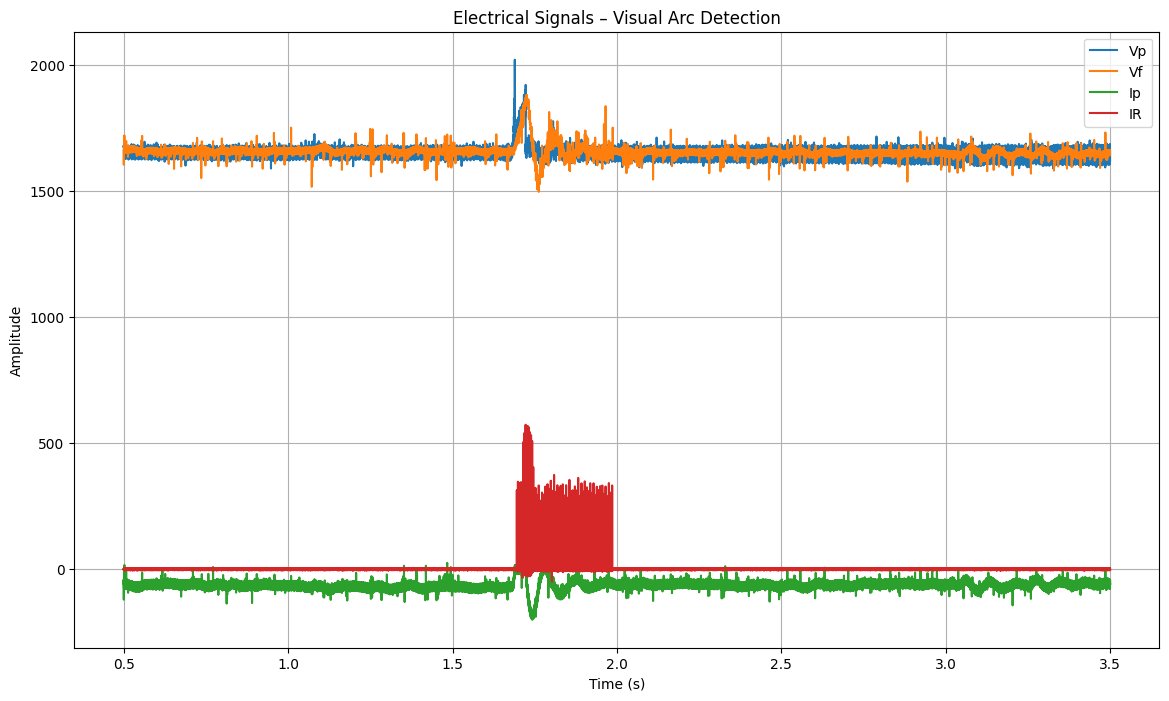

In [3]:
# Reading the data files
Vp1 = pd.read_csv("Fichiers/MM_B_1_Vp.txt", header=None, names=["Vp"])
x1  = pd.read_csv("Fichiers/MM_B_1_x.txt",  header=None, names=["time"])
Vf1 = pd.read_csv("Fichiers/MM_B_1_Vf.txt", header=None, names=["Vf"])
Ip1 = pd.read_csv("Fichiers/MM_B_1_Ip.txt", header=None, names=["Ip"])
IR1 = pd.read_csv("Fichiers/MM_B_1_IR.txt", header=None, names=["IR"])

# Concatenation of data into a single dataset
df1 = pd.concat([x1, Vp1, Vf1, Ip1, IR1], axis=1)

# Displaying electrical signals
plt.figure(figsize=(14,8))

# Plotting each signal against time
plt.plot(df1["time"], df1["Vp"], label="Vp")
plt.plot(df1["time"], df1["Vf"], label="Vf")
plt.plot(df1["time"], df1["Ip"], label="Ip")
plt.plot(df1["time"], df1["IR"], label="IR")

# Labels and title
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Electrical Signals – Visual Arc Detection")
plt.legend()
plt.grid(True)
plt.show()

Visually, the arc is clearly distinct in the first data sample. The data collected at the pantograph level is the most responsive; the phenomenon is detected first by Vp and Ip. Since the arcing phenomenon occurs at the catenary-pantograph interface, it is expected that a peak is observed slightly earlier in the Vp and Ip data than in the filtered Vf and IR data.

We have decided to use only Vp and Ip for future anomaly detection algorithms.

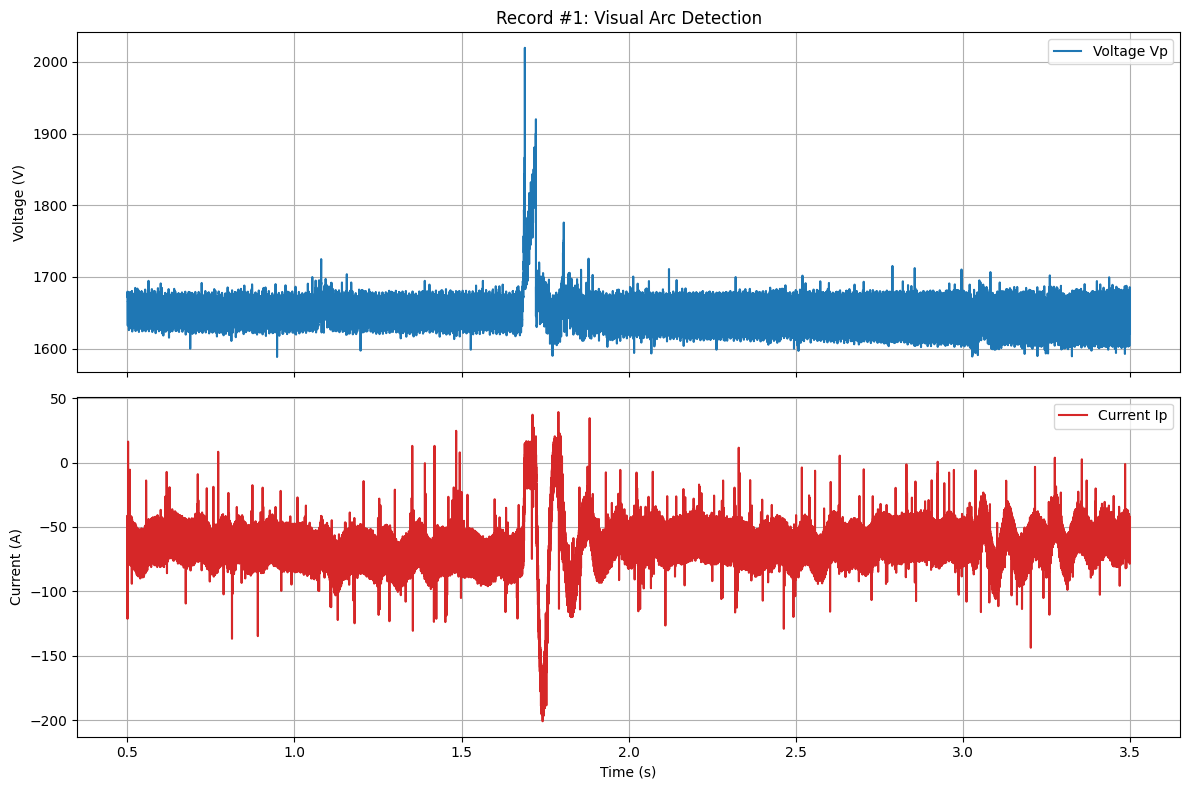

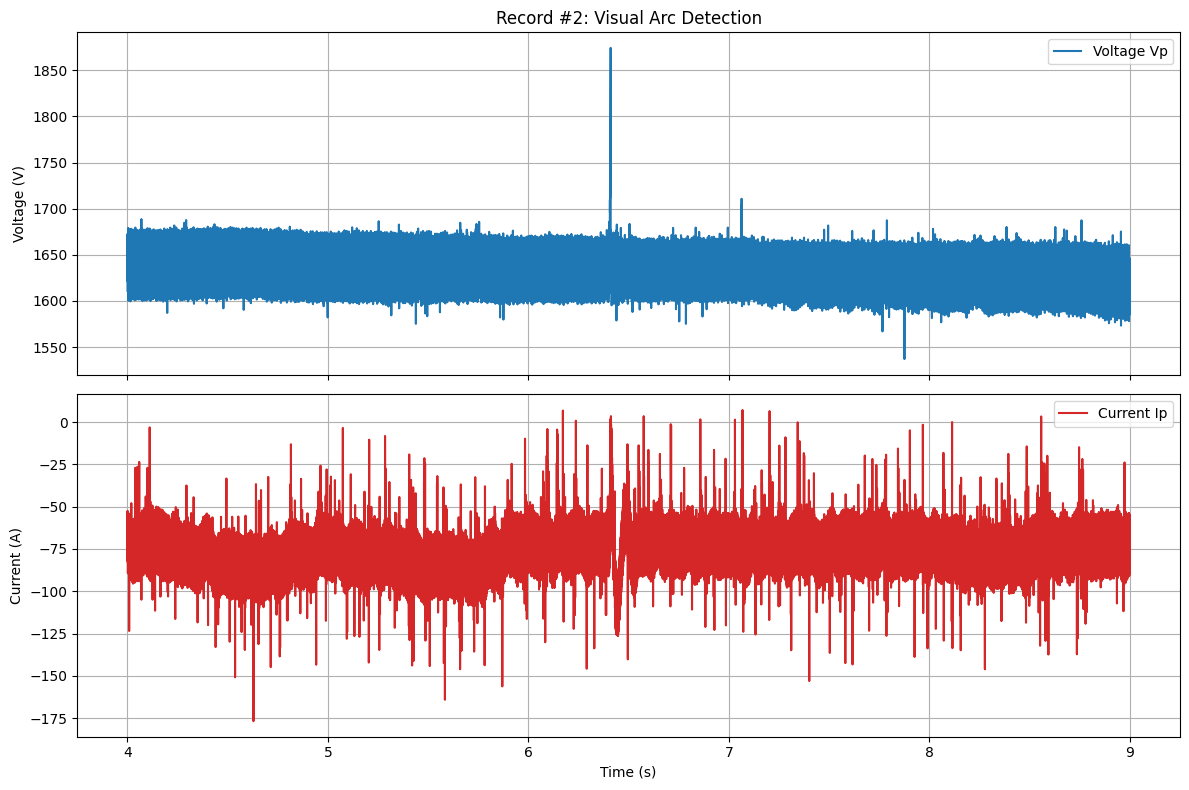

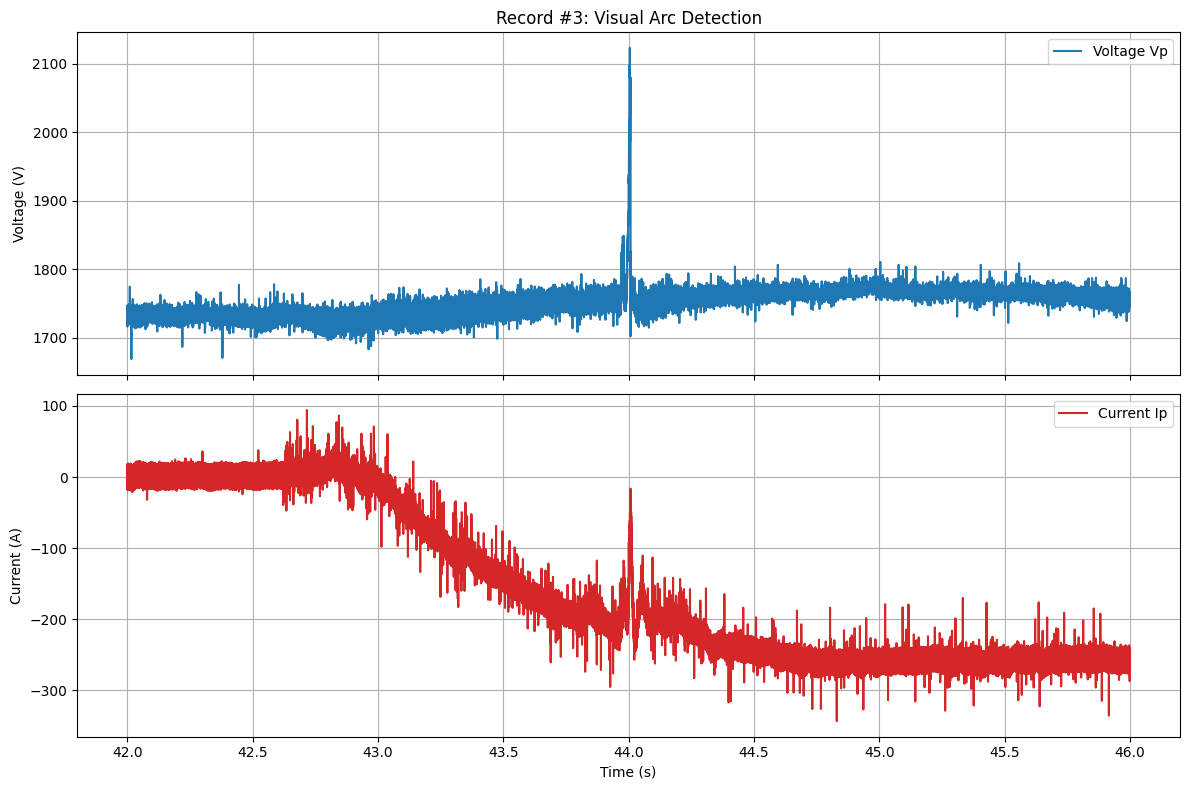

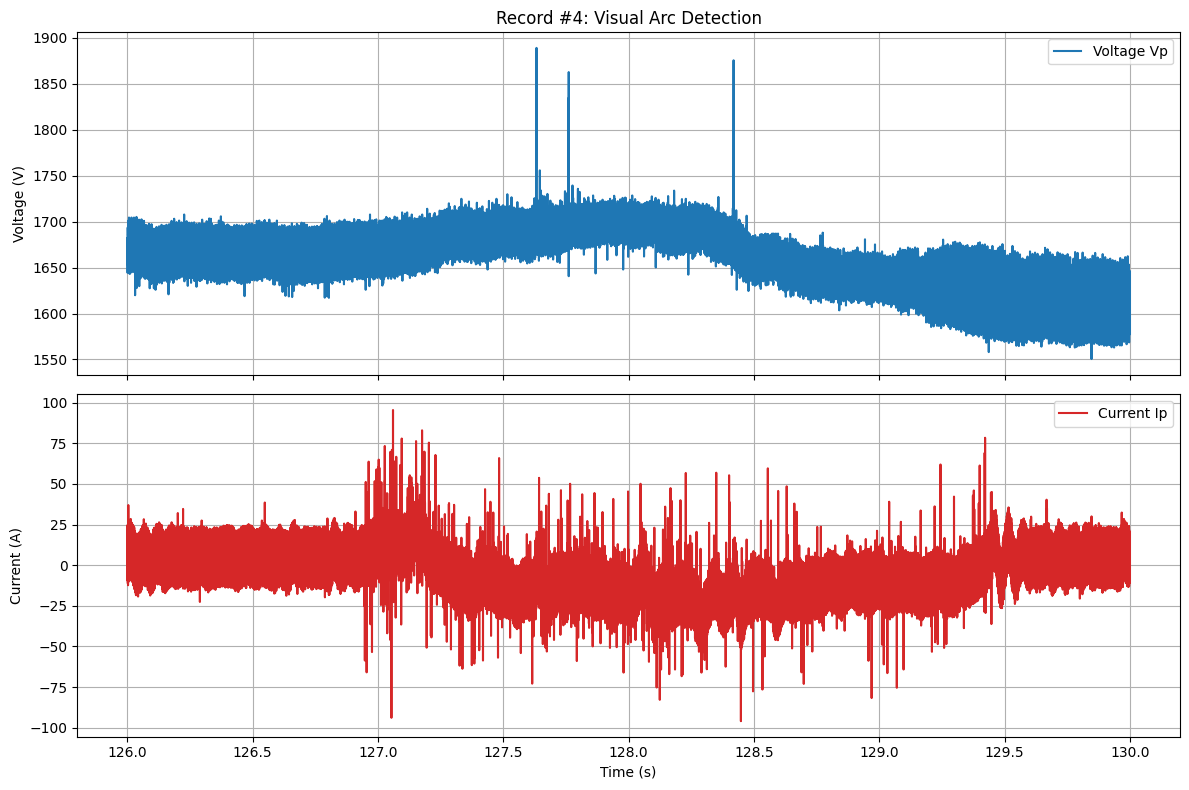

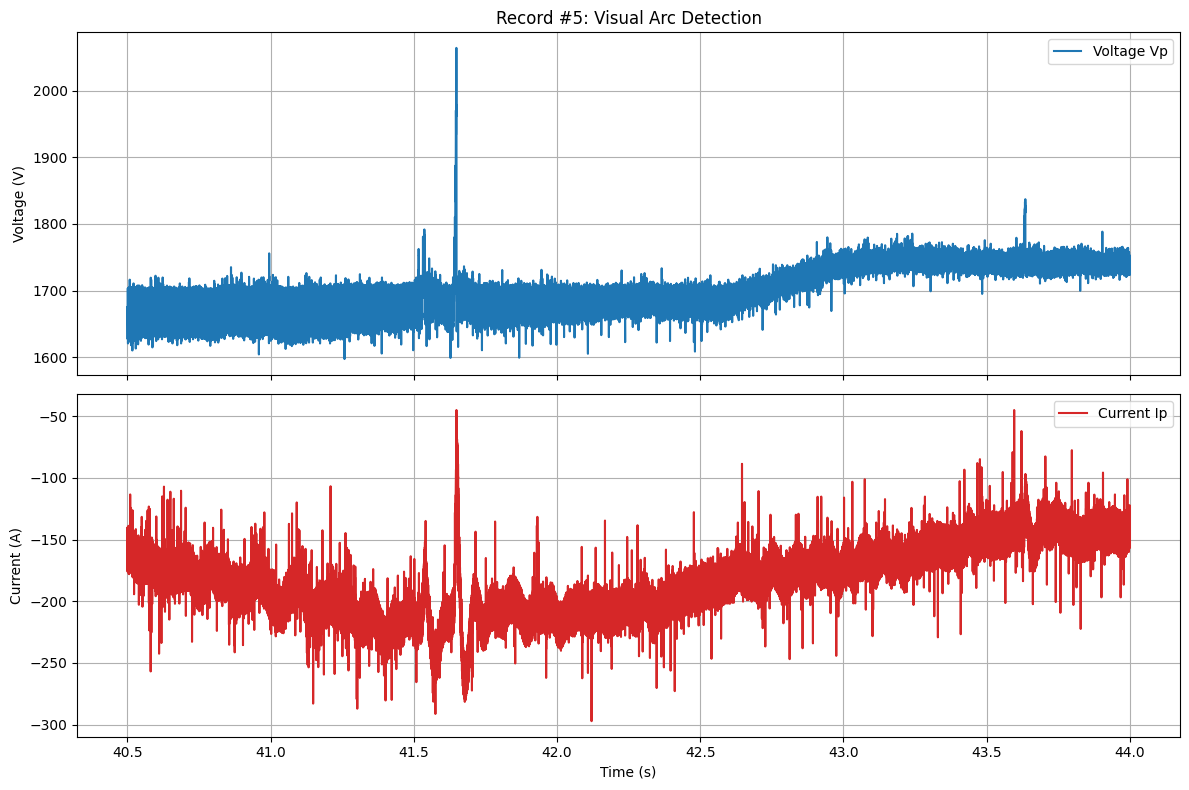

In [10]:
# Create a list containing the 5 pantograph voltage files matching the pattern
file_list = glob.glob("Fichiers/MM_B_*_Vp.txt")

# Loop through each file in the sorted list
for file_path in sorted(file_list):
    
    # Extract the unique braking ID from the filename (e.g., 'MM_B_1_Vp.txt' -> '1')
    braking_id = file_path.split('_')[2]
    
    try:
        # Load the corresponding datasets for Time, Voltage (Vp), and Current (Ip)
        t  = pd.read_csv(f"Fichiers/MM_B_{braking_id}_x.txt",  header=None, names=["time"])
        vp = pd.read_csv(f"Fichiers/MM_B_{braking_id}_Vp.txt", header=None, names=["Vp"])
        ip = pd.read_csv(f"Fichiers/MM_B_{braking_id}_Ip.txt", header=None, names=["Ip"])
        
        # Create a figure with 2 subplots sharing the X-axis (Time)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        
        # --- Plot 1: Pantograph Voltage Curve ---
        ax1.plot(t['time'], vp['Vp'], color='tab:blue', label='Voltage Vp')
        ax1.set_title(f"Record #{braking_id}: Visual Arc Detection")
        ax1.set_ylabel("Voltage (V)")
        ax1.grid(True)
        ax1.legend(loc='upper right')
        
        # --- Plot 2: Pantograph Current Curve ---
        ax2.plot(t['time'], ip['Ip'], color='tab:red', label='Current Ip')
        ax2.set_ylabel("Current (A)")
        ax2.set_xlabel("Time (s)")
        ax2.grid(True)
        ax2.legend(loc='upper right')
       
        # Adjust layout to prevent overlap and display the plot
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        # Error handling if a file is missing or corrupted
        print(f"Error reading braking event #{braking_id}: {e}")

Note : étudier la diminution de Ip comme détection d'arc

 On each sample visualisation we can observe arcs phenomenons (intensity and tension extremas)

Méthode des seuils dynamiques

Analyzing 5 files...


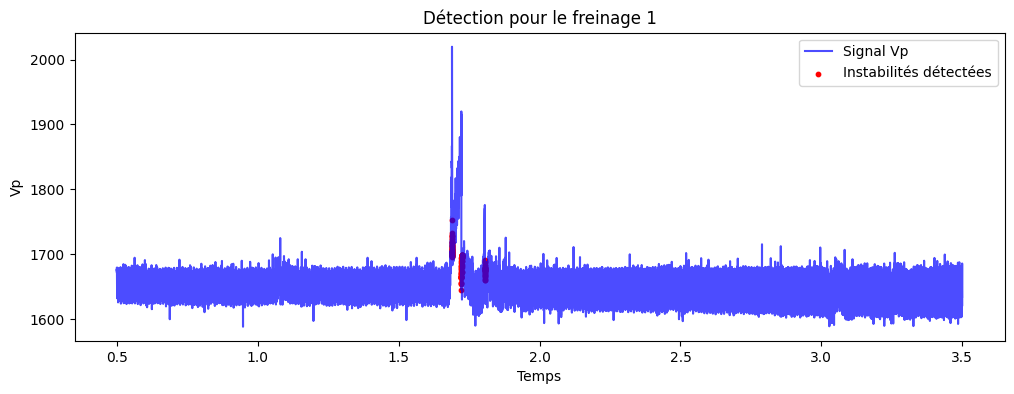

Échantillon 1 : Première anomalie détectée à t = 1.6895 (index 59475)


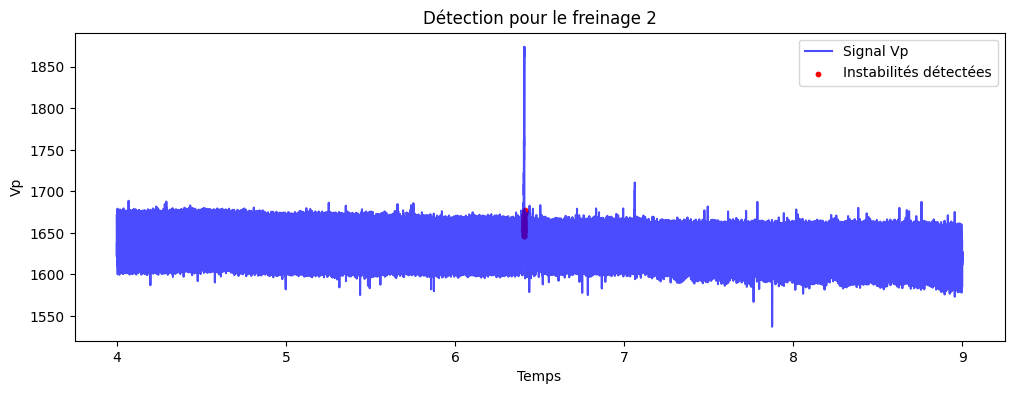

Échantillon 2 : Première anomalie détectée à t = 6.4103 (index 120516)


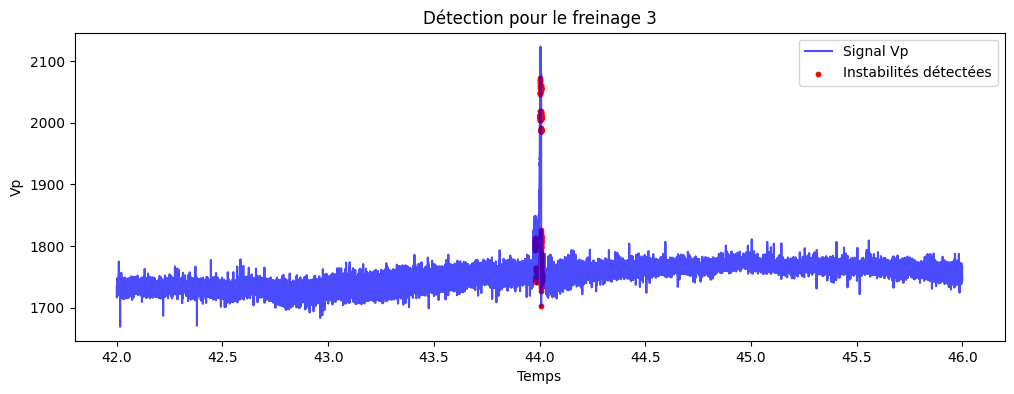

Échantillon 3 : Première anomalie détectée à t = 43.9770 (index 98853)


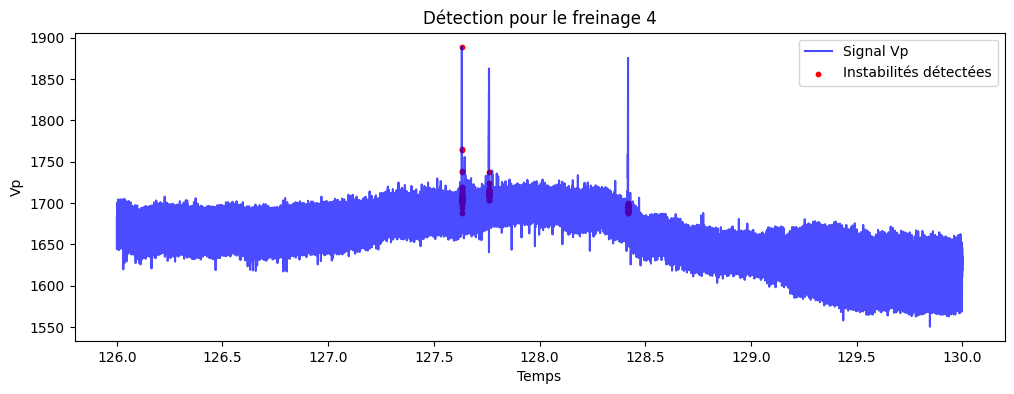

Échantillon 4 : Première anomalie détectée à t = 127.6324 (index 81620)


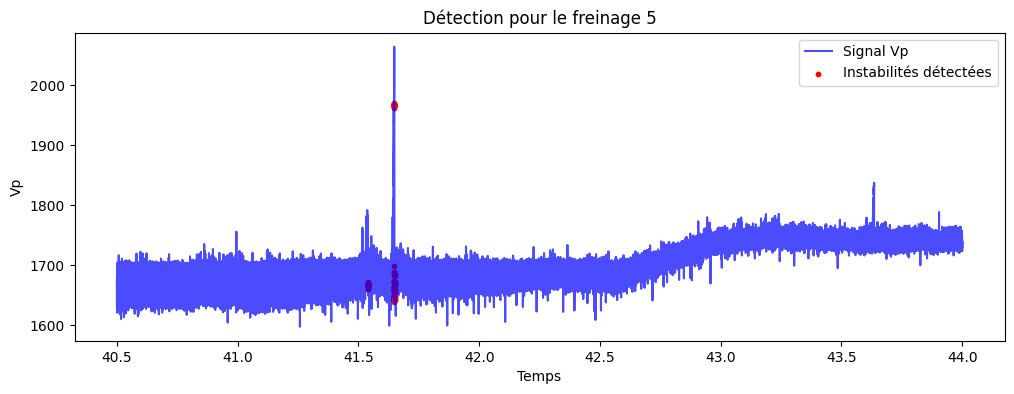

Échantillon 5 : Première anomalie détectée à t = 41.5393 (index 51966)
Normal Samples: 2014
Pre-Arc Samples: 5


C:\Users\lucas\AppData\Local\Temp\ipykernel_78248\1111059165.py:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


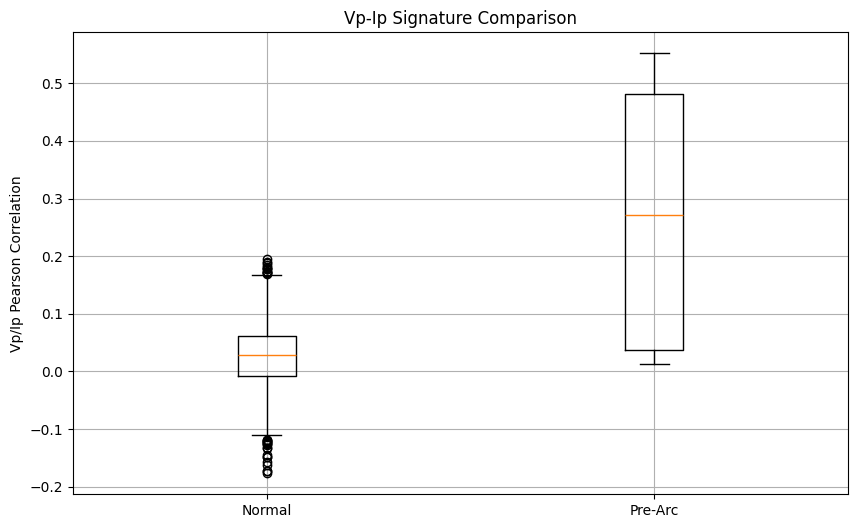

Normal samples generated: 2014


In [7]:
# Define window sizes and threshold parameters for anomaly detection
WINDOW_SIZE = 50       # Size of the rolling window for standard deviation calculation
PRE_ARC_WINDOW = 10000  # Number of points to analyze immediately before an arc
SIGMA_THRESHOLD = 5    # Multiplier for the standard deviation to set the detection threshold


# DATA LOADING HELPER FUNCTION

def load_braking_event(braking_id):
    """
    Loads Vp, x (time), and Ip files for a given braking ID and merges them into a single DataFrame.
    """
    prefix = f"Fichiers/MM_B_{braking_id}"
    try:
        vp = pd.read_csv(f"{prefix}_Vp.txt", header=None, names=["Vp"])
        x  = pd.read_csv(f"{prefix}_x.txt",  header=None, names=["time"])
        ip = pd.read_csv(f"{prefix}_Ip.txt", header=None, names=["Ip"])
        df = pd.concat([x, vp, ip], axis=1)
        return df
    except FileNotFoundError:
        return None

# Identify all available unique braking event IDs from the directory
vp_files = glob.glob("Fichiers/MM_B_*_Vp.txt")
braking_ids = sorted(list(set([f.split('_')[2] for f in vp_files])))

normal_correlations = []
pre_arc_correlations = []

print(f"Analyzing {len(braking_ids)} files...")

for b_id in braking_ids:
    df = load_braking_event(b_id)
    
    # Skip file if load failed or if data is too short for analysis
    if df is None or len(df) < (PRE_ARC_WINDOW * 2): 
        continue 
    
    # Calculate rolling standard deviation of Voltage (Vp) to detect instability
    df['Vp_std'] = df['Vp'].rolling(window=WINDOW_SIZE).std()
    
    # Define outlier threshold: Median of Std + (5 * Std of Std)
    median_std = df['Vp_std'].median()
    sigma_std = df['Vp_std'].std()
    threshold = median_std + (SIGMA_THRESHOLD * sigma_std)
    
    # Identify indices where volatility exceeds the calculated threshold
    unstable_indices = df.index[df['Vp_std'] > threshold].tolist()
 
    if unstable_indices:
        plt.figure(figsize=(12, 4))
        plt.plot(df['time'], df['Vp'], label='Signal Vp', color='blue', alpha=0.7)
        
        # Flag unstable indices in red
        plt.scatter(df['time'].iloc[unstable_indices], df['Vp'].iloc[unstable_indices], 
                    color='red', label='Instabilités détectées', s=10)
        
        plt.title(f"Détection pour le freinage {b_id}")
        plt.xlabel("Temps")
        plt.ylabel("Vp")
        plt.legend()
        plt.show()

    # CASE 1: ARC DETECTED (Instability found)
    if unstable_indices:
        onset_idx = unstable_indices[0] # First point of instability
        onset_time = df['time'].iloc[onset_idx]
        print(f"Échantillon {b_id} : Première anomalie détectée à t = {onset_time:.4f} (index {onset_idx})")
        
        # Analyze Pre-Arc Phase (Danger Zone) ---
        if onset_idx > PRE_ARC_WINDOW:
            danger_segment = df.iloc[onset_idx - PRE_ARC_WINDOW : onset_idx]
            
            # Check for sufficient variation before calculating correlation (avoid constant signals)
            if danger_segment['Vp'].std() > 0.1 and danger_segment['Ip'].std() > 0.1:
                corr = danger_segment['Vp'].corr(danger_segment['Ip'])
                pre_arc_correlations.append(corr)
      
        # Analyze Normal Phase (Before the Arc)
        # Define the end of the safe zone (well before the arc starts)
        safe_zone_end = onset_idx - 2000
        
        # Extract multiple samples of 200 points from the healthy period
        for i in range(50, safe_zone_end, 200):
            normal_segment = df.iloc[i : i + 200]
            
            if normal_segment['Vp'].std() > 0.1 and normal_segment['Ip'].std() > 0.1:
                normal_corr = normal_segment['Vp'].corr(normal_segment['Ip'])
                normal_correlations.append(normal_corr)
                
    # CASE 2: NO ARC DETECTED (Healthy File)
    else:
        # Take a sample slice from the middle of the file to represent "Normal" behavior
        mid = len(df) // 2
        normal_segment = df.iloc[mid : mid + PRE_ARC_WINDOW]
        
        if normal_segment['Vp'].std() > 0.1 and normal_segment['Ip'].std() > 0.1:
            normal_corr = normal_segment['Vp'].corr(normal_segment['Ip'])
            normal_correlations.append(normal_corr)

# Remove NaN values that might have resulted from constant signals or calculation errors
normal_correlations = [c for c in normal_correlations if not np.isnan(c)]
pre_arc_correlations = [c for c in pre_arc_correlations if not np.isnan(c)]

print(f"Normal Samples: {len(normal_correlations)}")
print(f"Pre-Arc Samples: {len(pre_arc_correlations)}")


# Plot boxplots to compare Vp/Ip correlation distributions between Normal and Pre-Arc states
plt.figure(figsize=(10, 6))
data = []
labels = []

if normal_correlations:
    data.append(normal_correlations)
    labels.append('Normal')
if pre_arc_correlations:
    data.append(pre_arc_correlations)
    labels.append('Pre-Arc')

if data:
    plt.boxplot(data, labels=labels)
    plt.grid(True)
    plt.ylabel("Vp/Ip Pearson Correlation")
    plt.title("Vp-Ip Signature Comparison")
    plt.show()

print(f"Normal samples generated: {len(normal_correlations)}")

We observe a higher current/voltage correlation during the pre-arc phase (which increases when reducing the size of the pre-arc window) compared to the 'Normal' phase. We have potentially identified a primary criterion for early arc detection

First predicitve algorithms : training and testing on each sample 

Model: Isolation Forest on two features: Standard deviation + Residual (Vp​ - median) over a 50-point rolling window.

Training: 10% of the sample data.
Threshold: 1.25× Maximum training phase score

File Fichiers\MM_B_1 loaded: 150001 points.


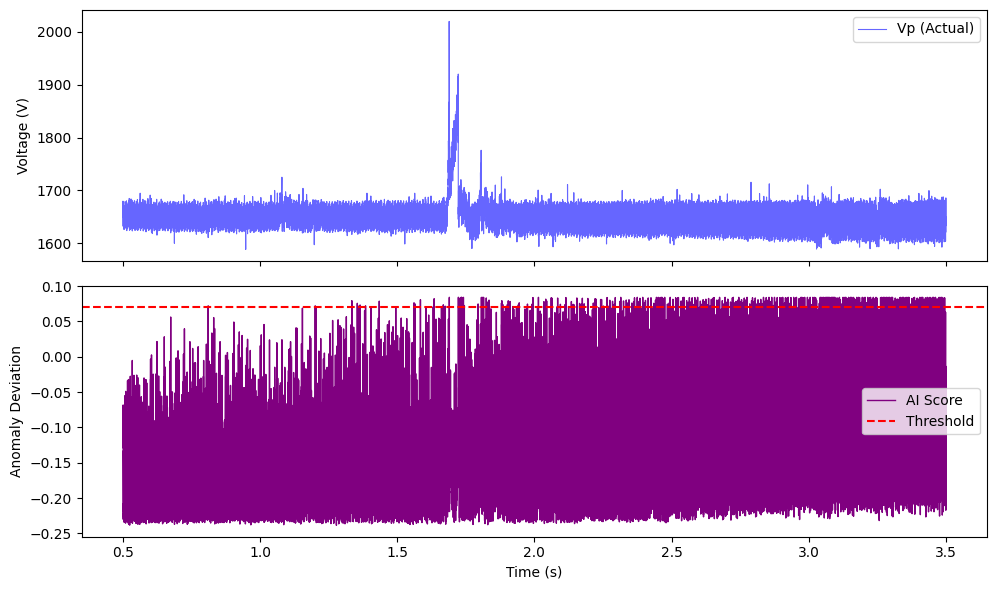

File Fichiers\MM_B_2 loaded: 250001 points.


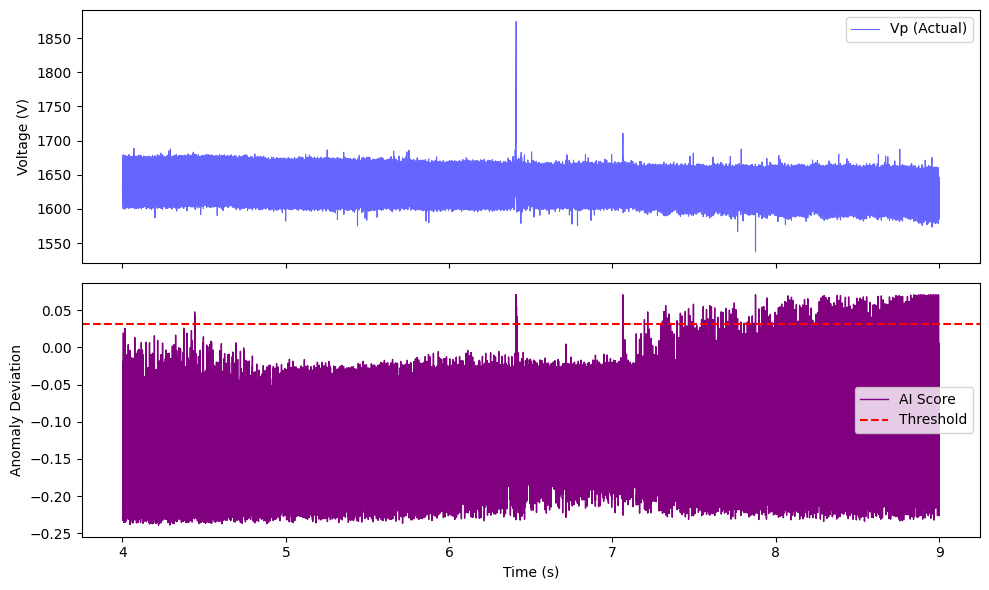

File Fichiers\MM_B_3 loaded: 200001 points.


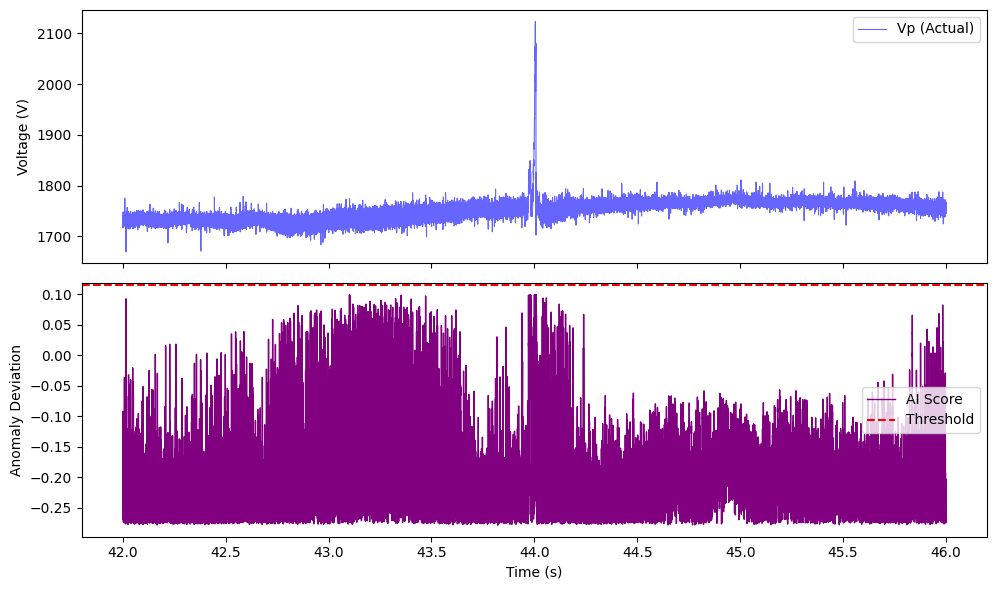

File Fichiers\MM_B_4 loaded: 200001 points.


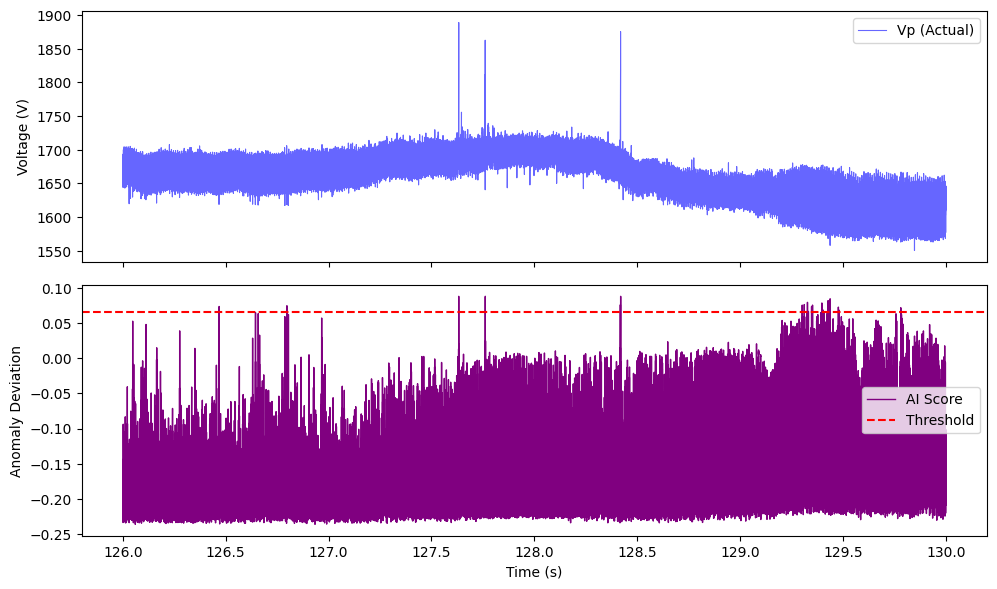

File Fichiers\MM_B_5 loaded: 175001 points.


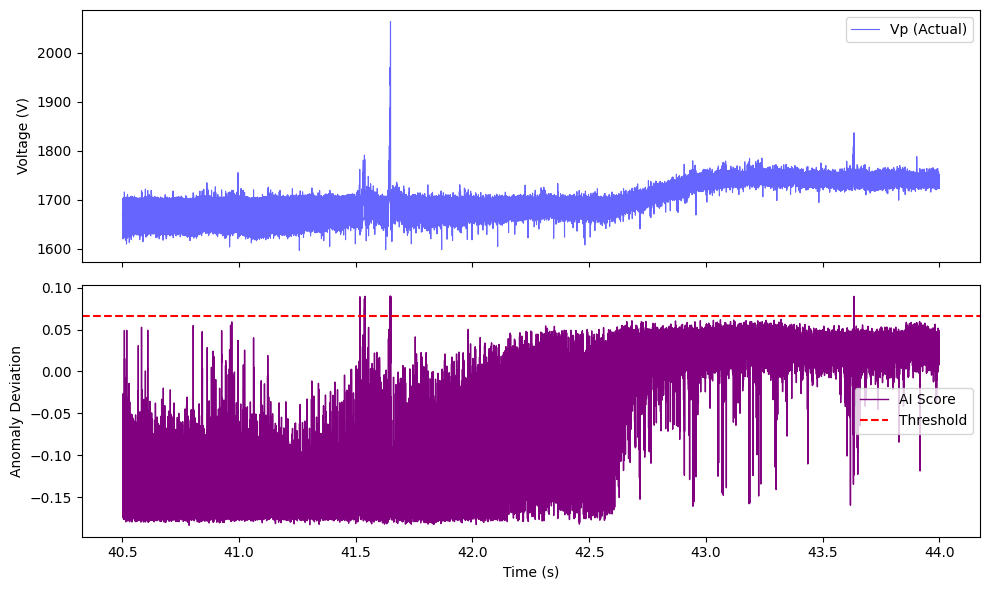

In [13]:
# Constants
WINDOW_SIZE = 50
NUM_TRAIN_POINTS = 15000

# Load list of files matching the pattern
files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

for vp_file in files:
    # Extract ID from filename (e.g., MM_B_01)
    ID_TO_TEST = "_".join(vp_file.split('_')[:3])
    try:
        # Load datasets: Voltage (Vp), Current (Ip), and Time
        vp = pd.read_csv(f"{ID_TO_TEST}_Vp.txt", header=None, names=["Vp"])
        ip = pd.read_csv(f"{ID_TO_TEST}_Ip.txt", header=None, names=["Ip"])
        time_data = pd.read_csv(f"{ID_TO_TEST}_x.txt", header=None, names=["Time"])

        # Align data lengths to the shortest file
        min_len = min(len(vp), len(ip), len(time_data))
        df = pd.concat(
            [time_data.iloc[:min_len], vp.iloc[:min_len], ip.iloc[:min_len]],
            axis=1
        )

        print(f"File {ID_TO_TEST} loaded: {len(df)} points.")

    except FileNotFoundError:
        print(f"Error: missing files for {ID_TO_TEST}")
        raise

    # Feature Engineering
    
    # Calculate rolling median to identify the trend (robust to outliers)
    trend_vp = df['Vp'].rolling(WINDOW_SIZE).median()

    # Feature 1: Absolute deviation from the trend
    df['Vp_Diff'] = (df['Vp'] - trend_vp).abs()

    # Feature 2: Rolling standard deviation (volatility)
    df['Vp_Std'] = df['Vp'].rolling(WINDOW_SIZE).std()

    # Prepare features for the model (drop NaNs created by rolling window)
    df_feat = df.dropna().copy()
    features = df_feat[['Vp_Diff', 'Vp_Std']]

    # Normalize features (important for distance/variance based models)
    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    # Split data: Train only on the first section (assumed to be 'normal')
    X_train = X[:NUM_TRAIN_POINTS]

    # Model Training
    
    model = IsolationForest(
        contamination=0.005,  # Estimated proportion of outliers in the data
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train)

    # Scoring & Thresholding

    # Invert decision_function so higher scores indicate higher anomaly likelihood
    df_feat['AI_Score'] = -model.decision_function(X)

    # Smooth the score to reduce noise/false positives
    df_feat['Smoothed_Score'] = df_feat['AI_Score'].rolling(5).mean().fillna(df_feat['AI_Score'])

    # Define a dynamic threshold based on the max score seen during training + margin
    threshold = df_feat['Smoothed_Score'].iloc[:NUM_TRAIN_POINTS].max() * 1.25

    # Visualization

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Plot 1: Actual Voltage
    ax1.plot(df['Time'], df['Vp'], label='Vp (Actual)', color='blue', linewidth=0.8, alpha=0.6)
    ax1.set_ylabel("Voltage (V)")
    ax1.legend()

    # Plot 2: AI Anomaly Score
    ax2.plot(df['Time'].iloc[-len(df_feat):], df_feat['Smoothed_Score'], 
             color='purple', linewidth=1, label="AI Score")
    ax2.axhline(threshold, color='red', linestyle='--', label="Threshold")
    ax2.set_ylabel("Anomaly Deviation")
    ax2.set_xlabel("Time (s)")
    ax2.legend(loc='center right')
    
    plt.tight_layout()
    plt.show()

4 anomalies on 5 are detected in advance

Isolation Forest on new features : la dérivée et le résidu (écart VP - médiane) sur une fenêtre de 50 valeurs

Entraînement sur 40 000 points, seuil = val abs du max phase d'entrainement x 1.1

File Fichiers\MM_B_1 loaded: 150001 points.


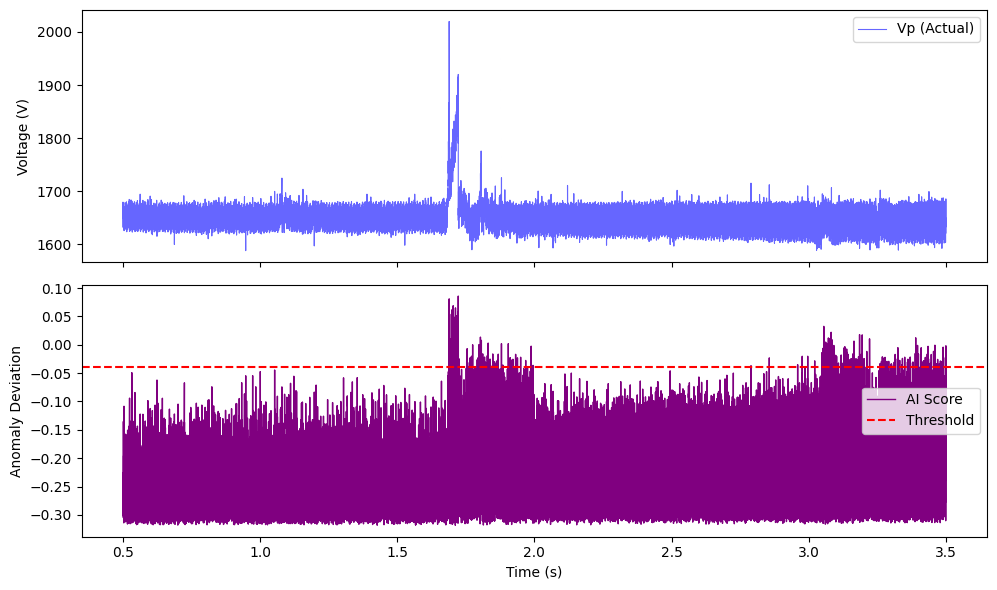

File Fichiers\MM_B_2 loaded: 250001 points.


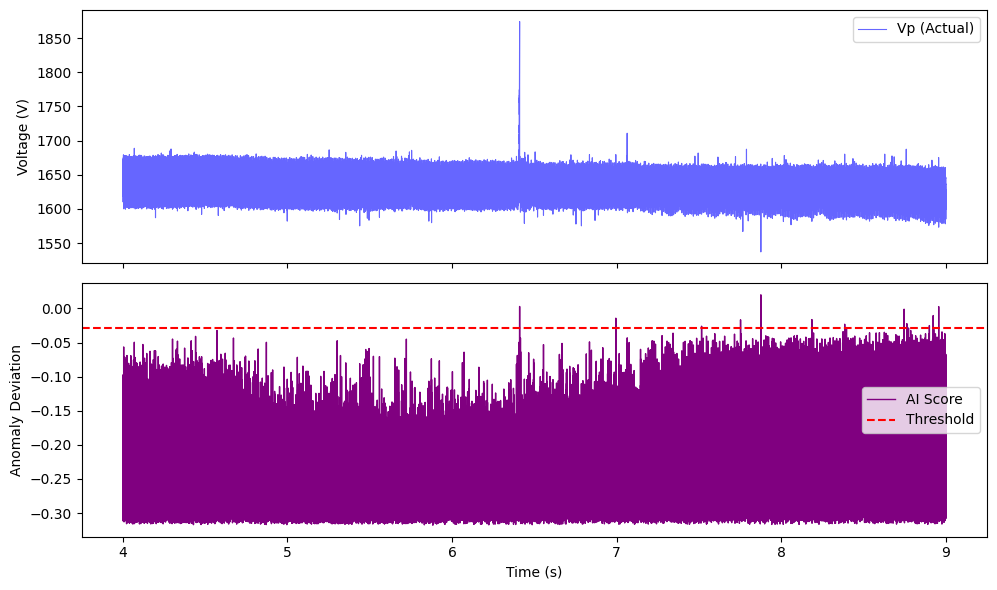

File Fichiers\MM_B_3 loaded: 200001 points.


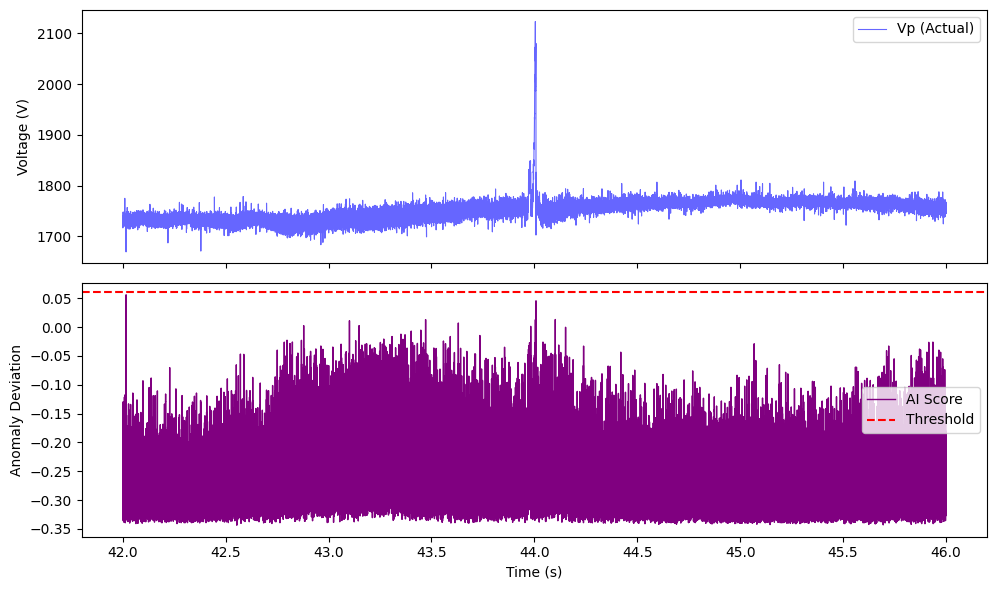

File Fichiers\MM_B_4 loaded: 200001 points.


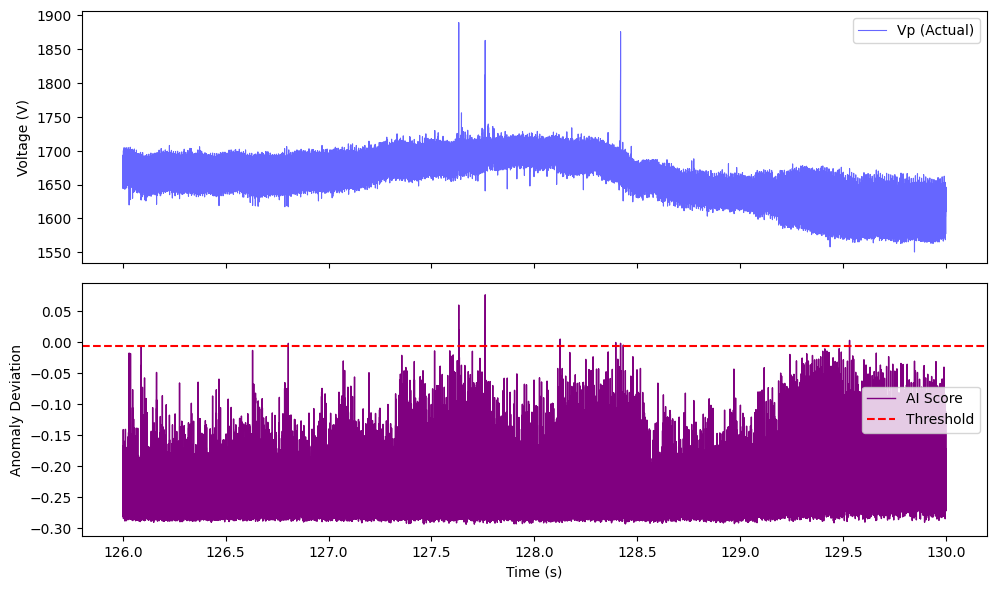

File Fichiers\MM_B_5 loaded: 175001 points.


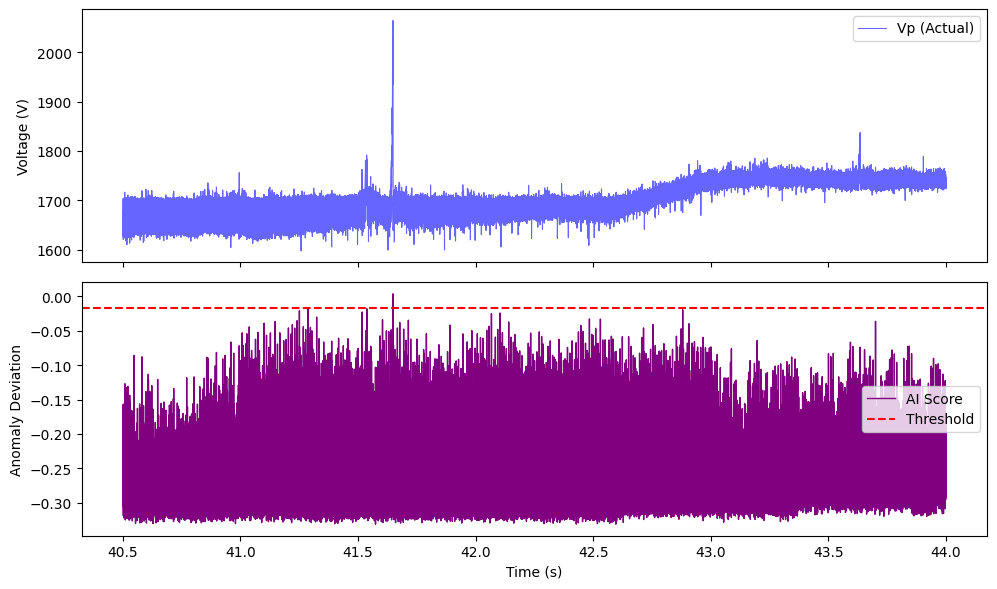

In [15]:
# Constants
WINDOW_SIZE = 50
NUM_TRAIN_POINTS = 40000  # Larger training set than previous version

files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

for vp_file in files:
    # Extract ID (e.g., MM_B_XX)
    ID_TO_TEST = "_".join(vp_file.split('_')[:3])
    try:
        # Load datasets
        vp = pd.read_csv(f"{ID_TO_TEST}_Vp.txt", header=None, names=["Vp"])
        ip = pd.read_csv(f"{ID_TO_TEST}_Ip.txt", header=None, names=["Ip"])
        time_data = pd.read_csv(f"{ID_TO_TEST}_x.txt", header=None, names=["Time"])

        min_len = min(len(vp), len(ip), len(time_data))
        df = pd.concat(
            [time_data.iloc[:min_len], vp.iloc[:min_len], ip.iloc[:min_len]],
            axis=1
        )

        print(f"File {ID_TO_TEST} loaded: {len(df)} points.")

    except FileNotFoundError:
        print(f"Error: missing files for {ID_TO_TEST}")
        raise

    # Feature Engineering

    # Rolling median to estimate the baseline trend
    trend_vp = df['Vp'].rolling(WINDOW_SIZE).median()

    # Feature 1: Residual
    # Deviation from the trend (Logic kept as is: Vp minus absolute trend)
    df['Residual'] = (df['Vp'] - trend_vp.abs())

    # Feature 2: Speed (Rate of Change)
    # Calculates the absolute difference between consecutive points to detect sudden spikes
    df['Speed'] = df['Vp'].diff().abs().fillna(0)
    
    df_feat = df.dropna().copy()

    # Select features for the model
    features = df_feat[['Residual', 'Speed']]

    # Normalize features (StandardScaler is crucial when mixing units like Volts and Volts/sec)
    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    # Model Training
    
    # Train on the first 40,000 points (assumed 'healthy' state)
    X_train = X[:NUM_TRAIN_POINTS]

    model = IsolationForest(
        contamination=0.005,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train)

    # Generate anomaly scores (inverted so high score = anomaly)
    df_feat['AI_Score'] = -model.decision_function(X)

    # Smooth the score over 5 points to reduce noise
    df_feat['Smoothed_Score'] = df_feat['AI_Score'].rolling(5).mean().fillna(df_feat['AI_Score'])

    # Dynamic Threshold Calculation
    
    # Find max score in training phase
    max_train_score = df_feat['Smoothed_Score'].iloc[:NUM_TRAIN_POINTS].max()
    
    # Set threshold with a 10% safety margin above the max training score
    threshold = max_train_score + abs(max_train_score) * 0.1

    # --- Visualization ---

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Plot 1: Actual Voltage
    ax1.plot(df['Time'], df['Vp'], label='Vp (Actual)', color='blue', linewidth=0.8, alpha=0.6)
    ax1.set_ylabel("Voltage (V)")
    ax1.legend()
    
    # Plot 2: AI Anomaly Score
    ax2.plot(df['Time'].iloc[-len(df_feat):], df_feat['Smoothed_Score'], 
             color='purple', linewidth=1, label="AI Score")
    ax2.axhline(threshold, color='red', linestyle='--', label="Threshold")
    ax2.set_ylabel("Anomaly Deviation")
    ax2.set_xlabel("Time (s)")
    ax2.legend(loc='center right')
    
    plt.tight_layout()
    plt.show()

Performs slightly less well than the Isolation Forest using standard deviation (only 2 detections here and a lower threshold) : though it can still be fine-tuned.

Conclusion of these two Isolation Forest : It seems to be performing well but impossible to use metrics to check their precision/recall and robustness

New method "Leave one out cross validation" : The training is done on normal phase of 4 samples, and the test on the fifth 

Goal : Checking robustness of the Isolation Forest by observing if the arc is detected before happening, and how long before

--- Chargement et Calibration Locale ---
Fichier MM_B_1 : calibré sur les 1000 premiers points.
Fichier MM_B_2 : calibré sur les 1000 premiers points.
Fichier MM_B_3 : calibré sur les 1000 premiers points.
Fichier MM_B_4 : calibré sur les 1000 premiers points.
Fichier MM_B_5 : calibré sur les 1000 premiers points.

--- Début de l'évaluation LOOCV ---

> Évaluation sur le fichier test : MM_B_1
  > Vraie anomalie à : 1.6895s
  > Alarme IA levée à : 1.6904s
   RETARD : Détection après l'arc de 0.0009 sec.
  Fausses alertes (bruit) : 0


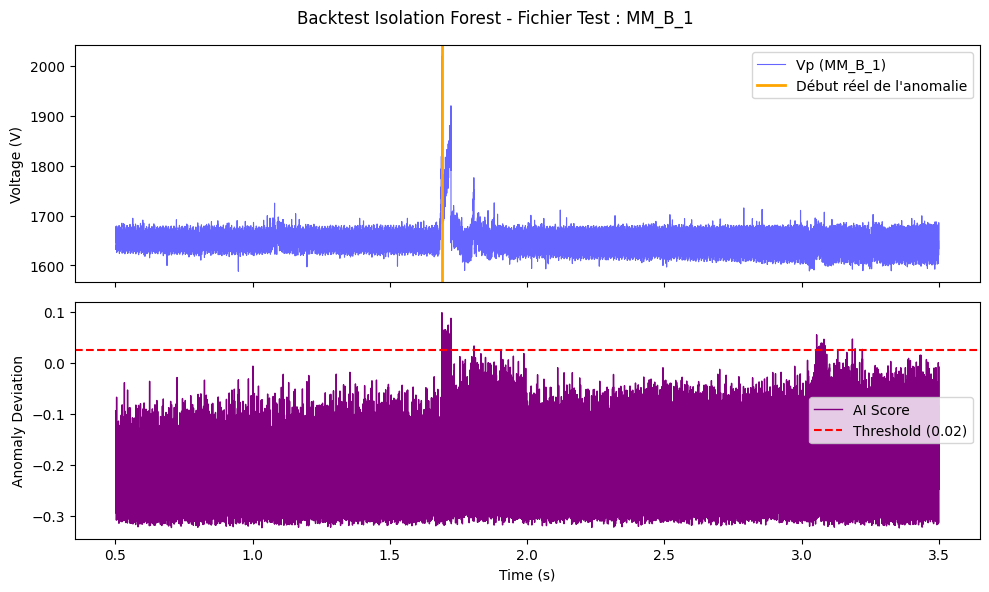


> Évaluation sur le fichier test : MM_B_2
  > Vraie anomalie à : 6.4103s
  ÉCHEC : L'IA n'a jamais dépassé le seuil.


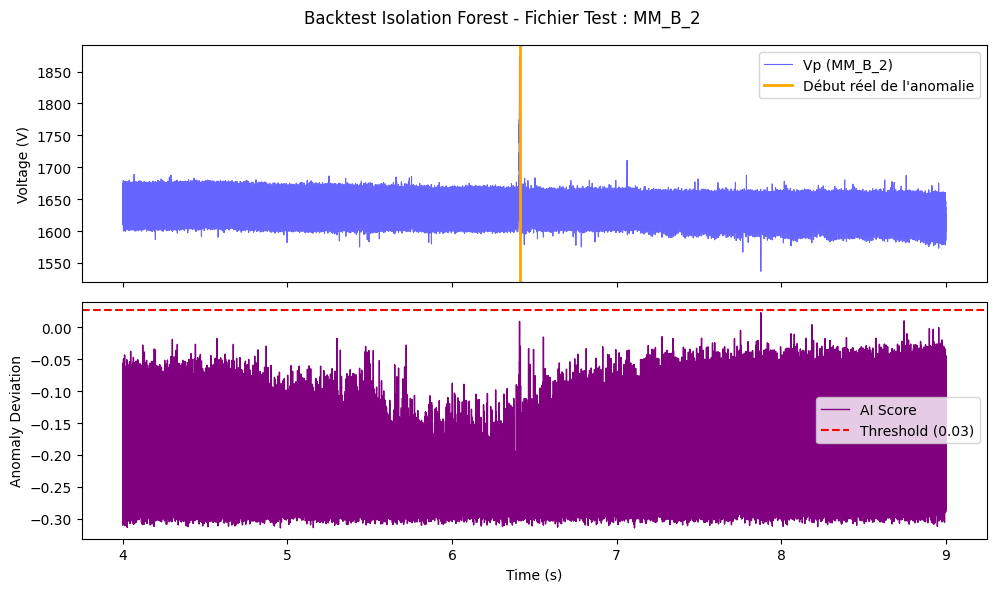


> Évaluation sur le fichier test : MM_B_3
  > Vraie anomalie à : 43.9770s
  > Alarme IA levée à : 42.0168s
  SUCCÈS : Anticipation de 1.9602 sec.
  Fausses alertes (bruit) : 2


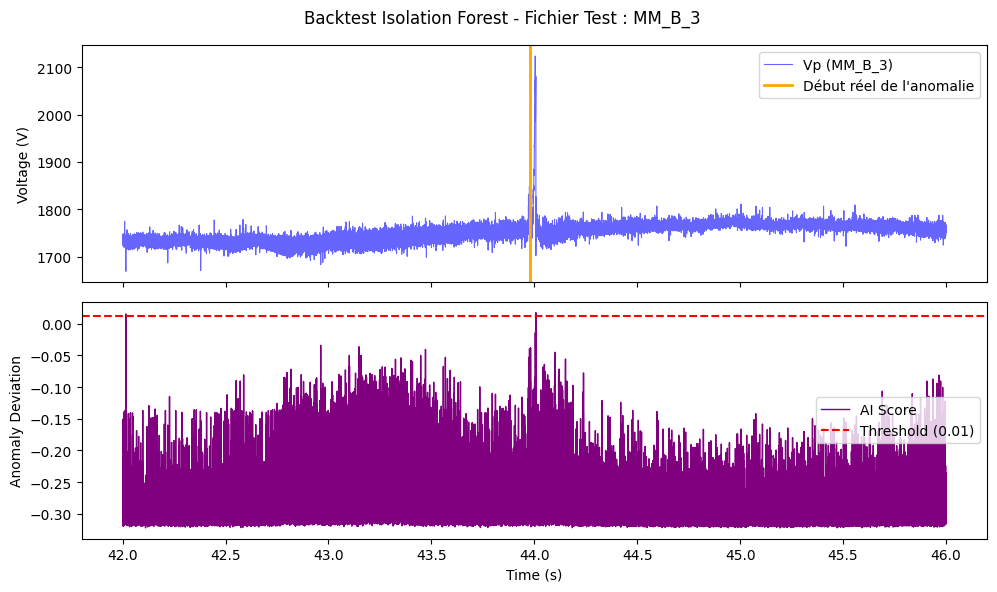


> Évaluation sur le fichier test : MM_B_4
  > Vraie anomalie à : 127.6324s
  > Alarme IA levée à : 127.6333s
   RETARD : Détection après l'arc de 0.0009 sec.
  Fausses alertes (bruit) : 0


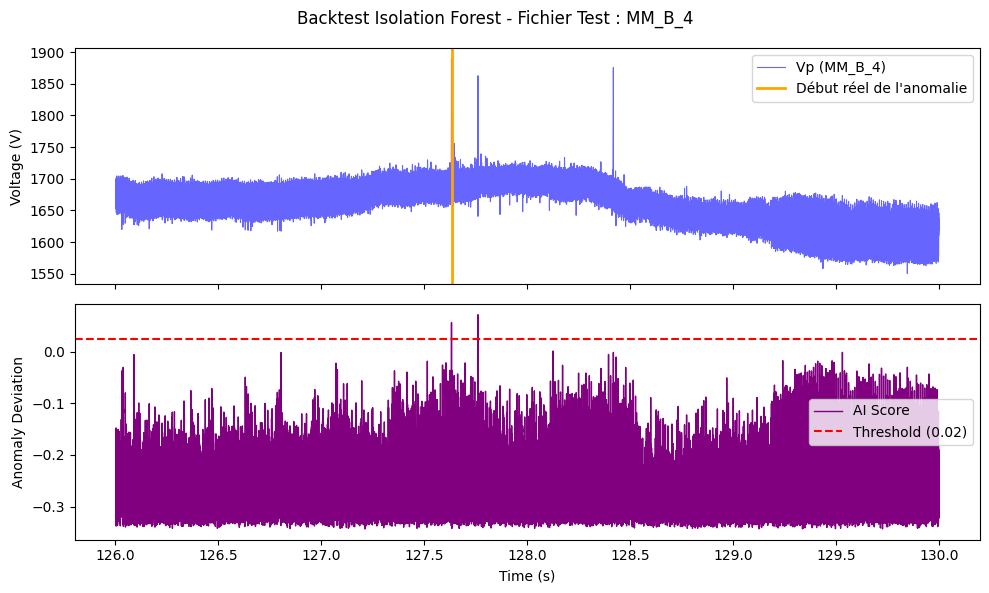


> Évaluation sur le fichier test : MM_B_5
  > Vraie anomalie à : 41.5393s
  > Alarme IA levée à : 41.5185s
  SUCCÈS : Anticipation de 0.0208 sec.
  Fausses alertes (bruit) : 0


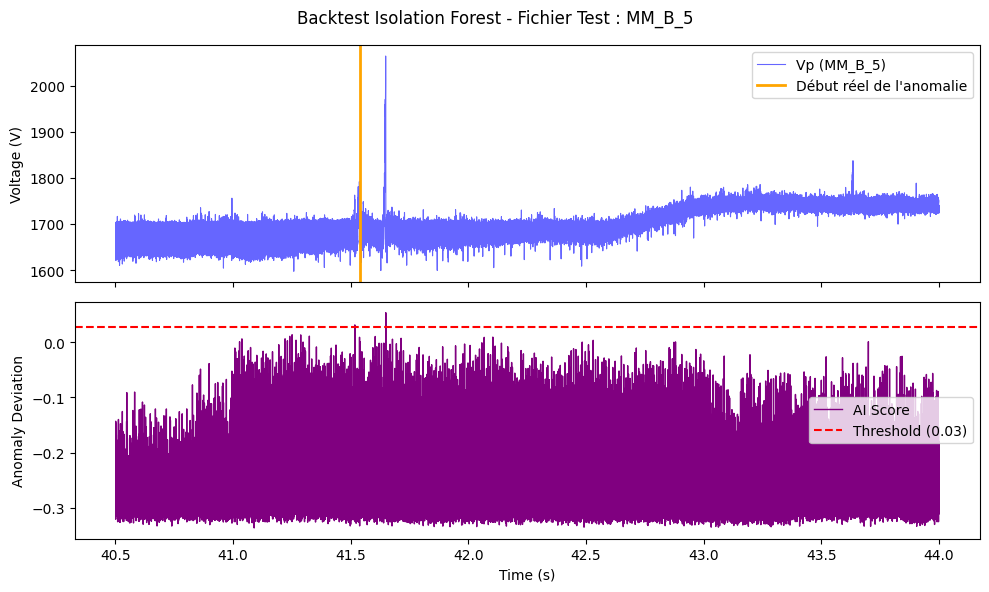

In [21]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Constants
WINDOW_SIZE = 50
CALIBRATION_POINTS = 1000
NUM_TRAIN_POINTS = 40000  # Size of the "healthy" baseline per file


files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

TRUE_ANOMALY_TIMES = {
    "MM_B_1": 1.6895,  
    "MM_B_2": 6.4103,
    "MM_B_3": 43.9770,
    "MM_B_4": 127.6324,
    "MM_B_5": 41.5393
}

# ==========================================
# STEP 1: LOAD ALL DATA AND CREATE FEATURES
# ==========================================
all_data = {}

print("--- Chargement et Calibration Locale ---")
for vp_file in files:
    # 1. On récupère juste le nom du fichier sans le dossier (ex: "MM_B_1_Vp.txt")
    nom_fichier = os.path.basename(vp_file)
    
    # 2. On extrait l'ID proprement ("MM_B_1")
    ID_TO_TEST = "_".join(nom_fichier.split('_')[:3])
    
    try:
        # 3. Attention ici : on doit réutiliser le chemin complet pour lire les fichiers, 
        # ou reconstruire le chemin en utilisant le dossier "Fichiers"
        dossier = os.path.dirname(vp_file) # "Fichiers"
        
        vp = pd.read_csv(f"{dossier}/{ID_TO_TEST}_Vp.txt", header=None, names=["Vp"])
        ip = pd.read_csv(f"{dossier}/{ID_TO_TEST}_Ip.txt", header=None, names=["Ip"])
        time_data = pd.read_csv(f"{dossier}/{ID_TO_TEST}_x.txt", header=None, names=["Time"])
        min_len = min(len(vp), len(ip), len(time_data))
        df = pd.concat([time_data.iloc[:min_len], vp.iloc[:min_len], ip.iloc[:min_len]], axis=1)

        # 1. Feature Engineering de base
        trend_vp = df['Vp'].rolling(WINDOW_SIZE).median()
        df['Residual'] = (df['Vp'] - trend_vp.abs())
        df['Speed'] = df['Vp'].diff().abs().fillna(0)
        
        df_feat = df.dropna().copy()
        
        # 2. NORMALISATION LOCALE (La clé de la robustesse ici)
        # On isole les 1000 premiers points (considérés 100% sains au démarrage)
        calib_data = df_feat[['Residual', 'Speed']].iloc[:CALIBRATION_POINTS]
        
        scaler = StandardScaler()
        # Le scaler apprend "l'état normal" de CE fichier spécifique
        scaler.fit(calib_data)
        
        # On applique cette normalisation à TOUT le fichier
        scaled_features = scaler.transform(df_feat[['Residual', 'Speed']])
        df_feat['Residual_scaled'] = scaled_features[:, 0]
        df_feat['Speed_scaled'] = scaled_features[:, 1]
        
        all_data[ID_TO_TEST] = df_feat
        print(f"Fichier {ID_TO_TEST} : calibré sur les {CALIBRATION_POINTS} premiers points.")

    except FileNotFoundError:
        print(f"Erreur: fichiers manquants pour {ID_TO_TEST}")
        continue


# ==========================================
# STEP 2: LEAVE-ONE-OUT CROSS-VALIDATION
# ==========================================
print("\n--- Début de l'évaluation LOOCV ---")

for test_id, test_df in all_data.items():
    print(f"\n> Évaluation sur le fichier test : {test_id}")
    
    # Séparer Train / Test
    train_dfs = [df for id_name, df in all_data.items() if id_name != test_id]
    
    # Construire le dataset d'entraînement (features déjà normalisées localement)
    train_features_list = []
    for t_df in train_dfs:
        healthy_portion = t_df[['Residual_scaled', 'Speed_scaled']].iloc[:NUM_TRAIN_POINTS]
        train_features_list.append(healthy_portion)
        
    X_train = pd.concat(train_features_list, axis=0).values
    X_test = test_df[['Residual_scaled', 'Speed_scaled']].values
    
    # Entraînement de l'Isolation Forest
    model = IsolationForest(contamination=0.005, random_state=42, n_jobs=-1)
    model.fit(X_train)
    
    # Calcul du seuil dynamique (sur les données d'entraînement)
    train_scores = -model.decision_function(X_train)
    smoothed_train_scores = pd.Series(train_scores).rolling(5).mean().fillna(pd.Series(train_scores))
    max_train_score = smoothed_train_scores.max()
    threshold = max_train_score + abs(max_train_score) * 0.1
    
    # Inférence sur le fichier test inédit
    test_df_results = test_df.copy()
    test_df_results['AI_Score'] = -model.decision_function(X_test)
    test_df_results['Smoothed_Score'] = test_df_results['AI_Score'].rolling(5).mean().fillna(test_df_results['AI_Score'])

    # --- MÉTRIQUES DE ROBUSTESSE ---
    alarm_indices = test_df_results.index[test_df_results['Smoothed_Score'] > threshold].tolist()
    
    # Récupération automatique du temps réel de l'anomalie depuis le dictionnaire
    if test_id not in TRUE_ANOMALY_TIMES:
        print(f"  ⚠️ ERREUR : L'ID '{test_id}' n'existe pas dans le dictionnaire TRUE_ANOMALY_TIMES.")
        print("  Veuillez vérifier le nom de vos fichiers.")
        continue # On passe au fichier suivant si l'ID n'est pas trouvé
        
    true_anomaly_time = TRUE_ANOMALY_TIMES[test_id]
    
    if alarm_indices:
        first_alarm_idx = alarm_indices[0]
        ai_alarm_time = test_df_results['Time'].iloc[first_alarm_idx]
        lead_time = true_anomaly_time - ai_alarm_time
        
        # Calcul des fausses alertes (Zone sûre s'arrêtant 0.5s avant l'arc)
        safe_zone_end_time = true_anomaly_time - 0.5 
        false_alarms = len(test_df_results[(test_df_results['Time'] < safe_zone_end_time) & 
                                           (test_df_results['Smoothed_Score'] > threshold)])
        
        print(f"  > Vraie anomalie à : {true_anomaly_time:.4f}s")
        print(f"  > Alarme IA levée à : {ai_alarm_time:.4f}s")
        
        if lead_time > 0:
            print(f"  SUCCÈS : Anticipation de {lead_time:.4f} sec.")
        else:
            print(f"   RETARD : Détection après l'arc de {abs(lead_time):.4f} sec.")
        print(f"  Fausses alertes (bruit) : {false_alarms}")
    else:
        print(f"  > Vraie anomalie à : {true_anomaly_time:.4f}s")
        print("  ÉCHEC : L'IA n'a jamais dépassé le seuil.")

    # --- VISUALISATION ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(test_df_results['Time'], test_df_results['Vp'], label=f'Vp ({test_id})', color='blue', linewidth=0.8, alpha=0.6)
    
    # La ligne orange se placera maintenant exactement au bon endroit pour chaque fichier
    ax1.axvline(true_anomaly_time, color='orange', linestyle='-', linewidth=2, label="Début réel de l'anomalie")
    ax1.set_ylabel("Voltage (V)")
    ax1.legend()
    
    # ... (le reste du code pour le plot ax2 reste identique) ...
    # Plot 2: AI Anomaly Score
    ax2.plot(test_df_results['Time'], test_df_results['Smoothed_Score'], 
             color='purple', linewidth=1, label="AI Score")
    ax2.axhline(threshold, color='red', linestyle='--', label=f"Threshold ({threshold:.2f})")
    ax2.set_ylabel("Anomaly Deviation")
    ax2.set_xlabel("Time (s)")
    ax2.legend(loc='center right')
    
    plt.suptitle(f"Backtest Isolation Forest - Fichier Test : {test_id}")
    plt.tight_layout()
    plt.show()

In [ ]:
scal

,Time,Vp,Ip,Residual,Speed
49,40.50096,1641.2961,-157.46849,2.63270,3.6200
50,40.50098,1642.6125,-156.52008,3.94910,1.3164
51,40.50100,1639.3216,-151.77803,0.65820,3.2909
52,40.50102,1647.5489,-153.04258,8.88550,8.2273
53,40.50104,1652.1562,-159.83951,13.49280,4.6073
...,...,...,...,...,...
174996,43.99990,1735.7459,-138.02609,0.49365,4.9364
174997,43.99992,1733.4422,-131.07109,-0.82275,2.3037
174998,43.99994,1737.0622,-139.29064,2.79725,3.6200
174999,43.99996,1731.7967,-146.87792,-1.64550,5.2655


Isolation Forest avec deux features : corrélation Ip/Vp et écart-type (ne semble pas fonctionner)

Fichier MM_B_1 chargé : 150001 points.


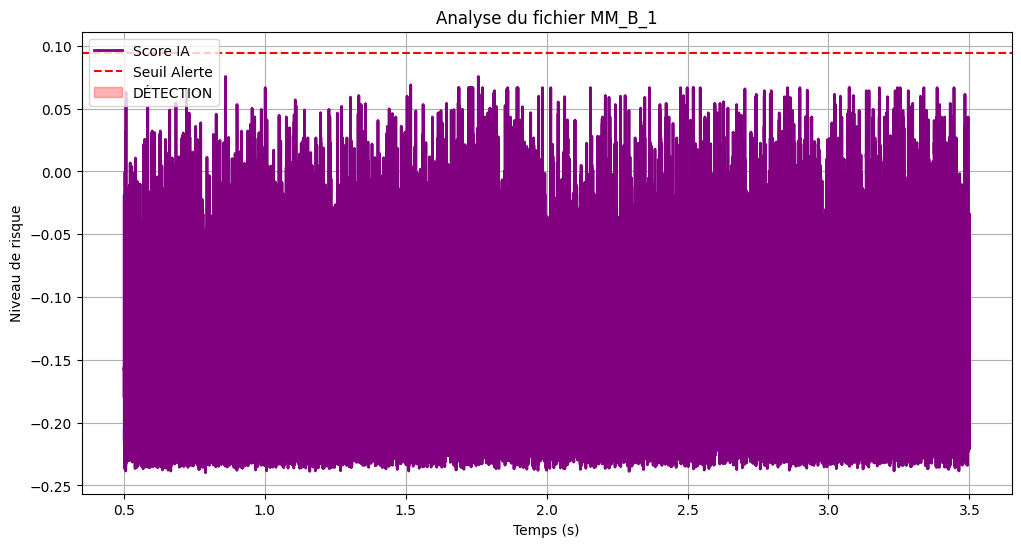

In [4]:
ID_A_TESTER = "MM_B_1"  
FENETRE = 50            

try:
    vp = pd.read_csv(f"Fichiers/{ID_A_TESTER}_Vp.txt", header=None, names=["Vp"])
    ip = pd.read_csv(f"Fichiers/{ID_A_TESTER}_Ip.txt", header=None, names=["Ip"])
    temps = pd.read_csv(f"Fichiers/{ID_A_TESTER}_x.txt", header=None, names=["Time"])
    
    df = pd.concat([temps, vp, ip], axis=1)
    print(f"Fichier {ID_A_TESTER} chargé : {len(df)} points.")

except FileNotFoundError:
    print(f"Erreur : Impossible de trouver les fichiers pour {ID_A_TESTER}")
    exit()

# 2. CALCUL DES INDICATEURS (FEATURES)
# On garde la même taille que l'original en remplaçant les trous par 0
df['Corr'] = df['Vp'].rolling(FENETRE).corr(df['Ip']).fillna(0)
df['Std']  = df['Vp'].rolling(FENETRE).std().fillna(0)

# 3. L'IA (ISOLATION FOREST)
# On prépare les données pour l'IA
features = df[['Corr', 'Std']]

# On entraîne l'IA seulement sur les 400 premiers points (Zone calme)
# On suppose que le train roule normalement au début de l'enregistrement
scaler = StandardScaler()
X_train = scaler.fit_transform(features.iloc[:400])

model = IsolationForest(contamination=0.01, random_state=42)
model.fit(X_train)

# 4. PRÉDICTION
# On teste sur TOUT le fichier
X_complet = scaler.transform(features)
# Le score est inversé : Plus il est haut, plus c'est grave
df['Score_IA'] = -model.decision_function(X_complet)

# 5. AFFICHAGE
plt.figure(figsize=(12, 6))

# Courbe du Score d'Anomalie (Violet)
plt.plot(df['Time'], df['Score_IA'], color='purple', label="Score IA", linewidth=2)

# Ligne Rouge d'Alerte (Basée sur le max du début calme)
seuil = df['Score_IA'].iloc[:400].max() * 1.5
plt.axhline(y=seuil, color='red', linestyle='--', label="Seuil Alerte")

# Colorier quand ça dépasse
plt.fill_between(df['Time'], -0.5, df['Score_IA'], 
                 where=(df['Score_IA'] > seuil), 
                 color='red', alpha=0.3, label="DÉTECTION")

plt.title(f"Analyse du fichier {ID_A_TESTER}")
plt.xlabel("Temps (s)")
plt.ylabel("Niveau de risque")
plt.legend()
plt.grid(True)
plt.show()



AUTOENCODERS

Autoencoder 1 : residual and standard deviation

--- Fichiers\MM_B_1 ---
ARC DETECTED AT: 1.6894 s


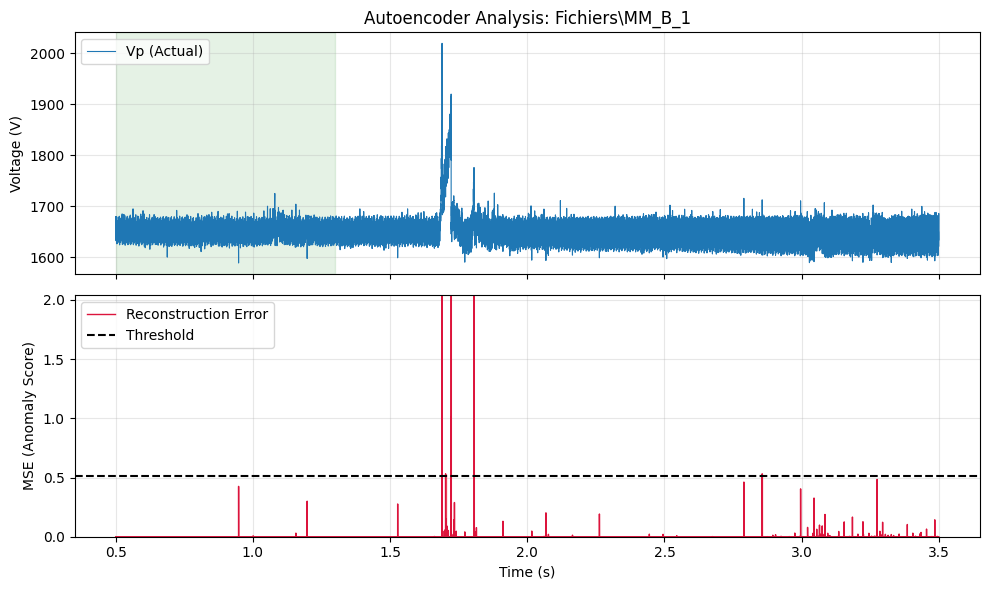

--- Fichiers\MM_B_2 ---
ARC DETECTED AT: 6.4096 s


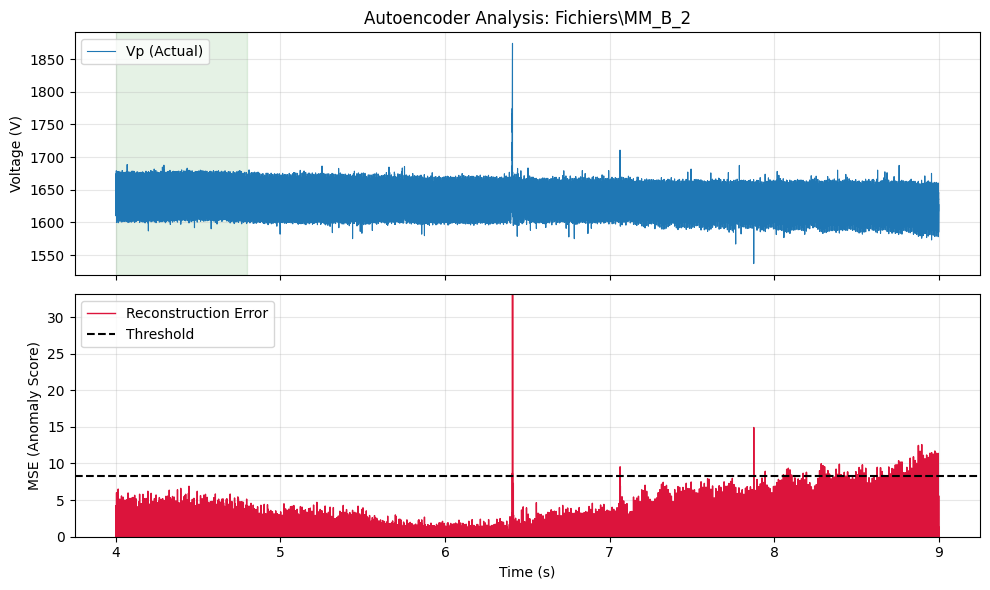

--- Fichiers\MM_B_3 ---
ARC DETECTED AT: 43.1014 s


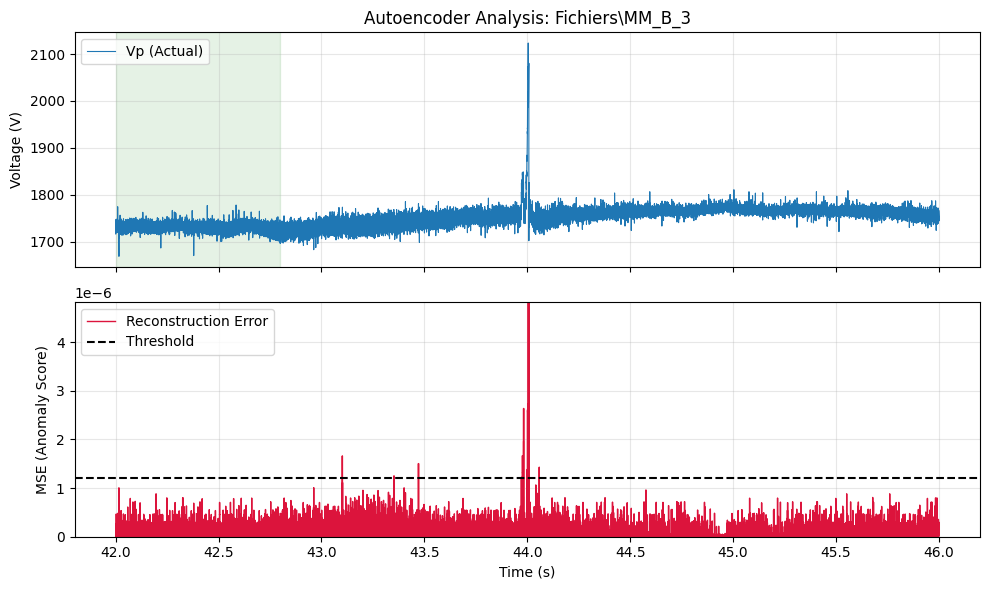

--- Fichiers\MM_B_4 ---
ARC DETECTED AT: 127.6322 s


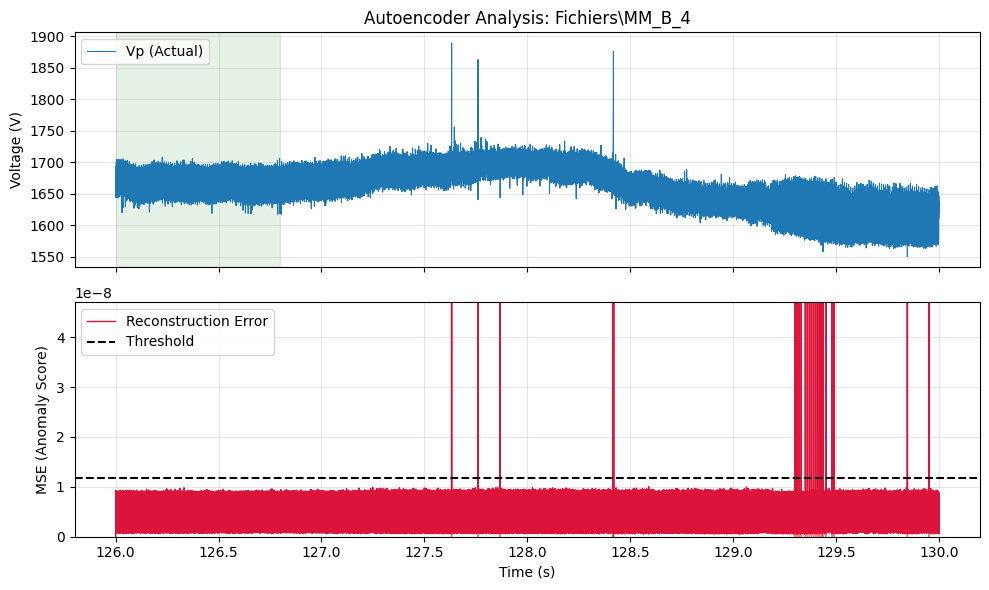

--- Fichiers\MM_B_5 ---
ARC DETECTED AT: 41.5393 s


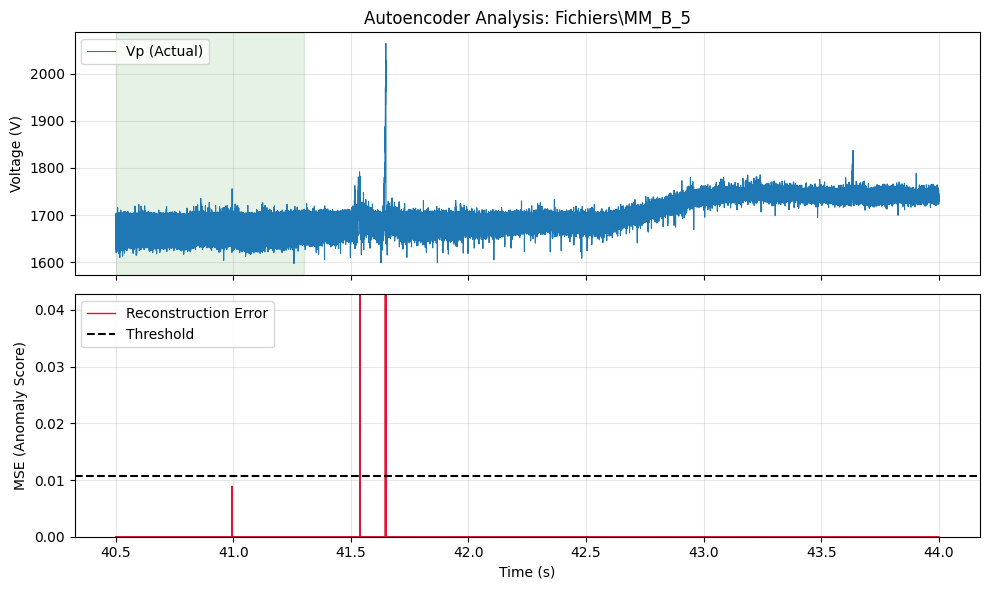

In [5]:
TREND_WINDOW = 50
NUM_TRAIN_POINTS = 40000  # Training on the "quiet/stable" phase
THRESHOLD_MARGIN = 1.2    # Safety margin above max noise (20%)

files = sorted(glob.glob("Fichiers/MM_B_*_Vp.txt"))

for vp_file in files:
    ID_TO_TEST = "_".join(vp_file.split('_')[:3])
    
    try:
        # 1. LOAD DATA
        vp = pd.read_csv(f"{ID_TO_TEST}_Vp.txt", header=None, names=["Vp"])
        time_data = pd.read_csv(f"{ID_TO_TEST}_x.txt", header=None, names=["Time"])
        
        min_len = min(len(vp), len(time_data))
        df = pd.concat([time_data.iloc[:min_len], vp.iloc[:min_len]], axis=1)
        
        # 2. FEATURE ENGINEERING
        # Trend (Rolling Median)
        trend_vp = df['Vp'].rolling(TREND_WINDOW).median().bfill()
        
        # Feature 1: Residual (Deviation from trend)
        df['Residual'] = (df['Vp'] - trend_vp).abs()
        
        # Feature 2: Standard Deviation (Global)
        # Note: current logic applies the global std to the whole column
        df['Std_Dev'] = df['Vp'].std()
        
        # Prepare input data
        features_columns = ['Residual', 'Std_Dev']
        data = df[features_columns].values
        
        # 3. NORMALIZATION
        scaler = StandardScaler()
        # Fit scaler ONLY on training data to avoid data leakage
        scaler.fit(data[:NUM_TRAIN_POINTS])
        data_scaled = scaler.transform(data)
        
        X_train = data_scaled[:NUM_TRAIN_POINTS]
        
        # 4. AUTOENCODER BUILD
        input_dim = X_train.shape[1]
        
        input_layer = Input(shape=(input_dim,))
        
        # Encoder: Compress features
        encoder = Dense(8, activation="relu")(input_layer)
        encoder = Dense(4, activation="relu")(encoder)
        
        # Bottleneck: Latent space representation
        bottleneck = Dense(2, activation="relu")(encoder)
        
        # Decoder: Attempt reconstruction
        decoder = Dense(4, activation="relu")(bottleneck)
        decoder = Dense(8, activation="relu")(decoder)
        output_layer = Dense(input_dim, activation="linear")(decoder)
        
        autoencoder = Model(inputs=input_layer, outputs=output_layer)
        
        # Compile (minimize reconstruction error)
        autoencoder.compile(optimizer='adam', loss='mse')
        
        # Train
        autoencoder.fit(X_train, X_train, 
                        epochs=20, 
                        batch_size=32, 
                        shuffle=True, 
                        verbose=0)
        
        # 5. DETECTION
        reconstructions = autoencoder.predict(data_scaled, verbose=0)
        
        # Calculate MSE (Mean Squared Error) per point
        mse = np.mean(np.power(data_scaled - reconstructions, 2), axis=1)
        
        df['Reconstruction_Error'] = mse
        
        # Smooth error to reduce noise
        df['Error_Smoothed'] = df['Reconstruction_Error'].rolling(5).mean().fillna(0)

        # 6. DYNAMIC THRESHOLD
        # Based on max error in the training phase
        max_train_error = df['Error_Smoothed'].iloc[:NUM_TRAIN_POINTS].max()
        threshold = max_train_error * THRESHOLD_MARGIN
        
        # Identify anomalies
        anomalies = df[(df['Error_Smoothed'] > threshold) & (df.index > NUM_TRAIN_POINTS)]
        
        print(f"--- {ID_TO_TEST} ---")
        if not anomalies.empty:
            t_first = anomalies['Time'].iloc[0]
            print(f"ARC DETECTED AT: {t_first:.4f} s")
        else:
            print("No arc detected.")

        # 7. PLOTTING
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

        # Top: Physical Signal
        ax1.plot(df['Time'], df['Vp'], label='Vp (Actual)', color='#1f77b4', linewidth=0.8)
        ax1.axvspan(df['Time'].iloc[0], df['Time'].iloc[NUM_TRAIN_POINTS], color='green', alpha=0.1)
        ax1.set_ylabel("Voltage (V)")
        ax1.legend(loc='upper left')
        ax1.set_title(f"Autoencoder Analysis: {ID_TO_TEST}")
        ax1.grid(True, alpha=0.3)

        # Bottom: Reconstruction Error
        ax2.plot(df['Time'], df['Error_Smoothed'], color='crimson', linewidth=1, label="Reconstruction Error")
        ax2.axhline(threshold, color='black', linestyle='--', linewidth=1.5, label="Threshold")
        
        # Fill anomaly zone
        ax2.fill_between(df['Time'], 0, df['Error_Smoothed'], 
                         where=(df['Error_Smoothed'] > threshold), color='red', alpha=0.5)

        # Smart Zoom
        ax2.set_ylim(0, threshold * 4)
        
        ax2.set_ylabel("MSE (Anomaly Score)")
        ax2.set_xlabel("Time (s)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error processing {ID_TO_TEST}: {e}")

3 arcs detected in advance, all five arcs are detected when they occur

Auto-encoder tentative 2 : velocity and residual

C:\Users\lucas\AppData\Local\Temp\ipykernel_95408\2023551968.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trend_vp = df['Vp'].rolling(TREND_WINDOW).median().fillna(method='bfill')


--- MM_B_1 ---
ARC DETECTED AT: 1.4346 s


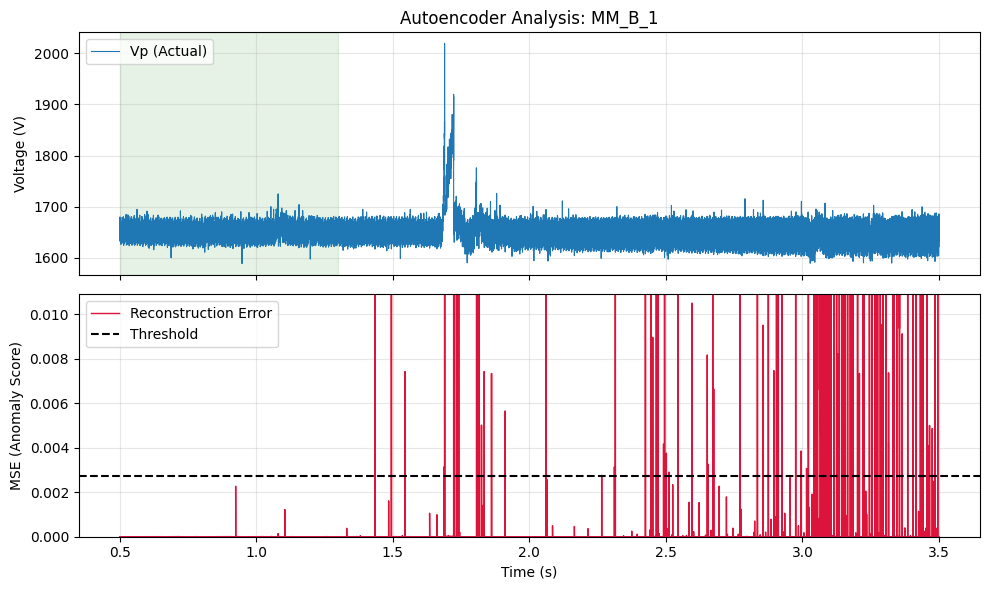

C:\Users\lucas\AppData\Local\Temp\ipykernel_95408\2023551968.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trend_vp = df['Vp'].rolling(TREND_WINDOW).median().fillna(method='bfill')


--- MM_B_2 ---
ARC DETECTED AT: 4.8884 s


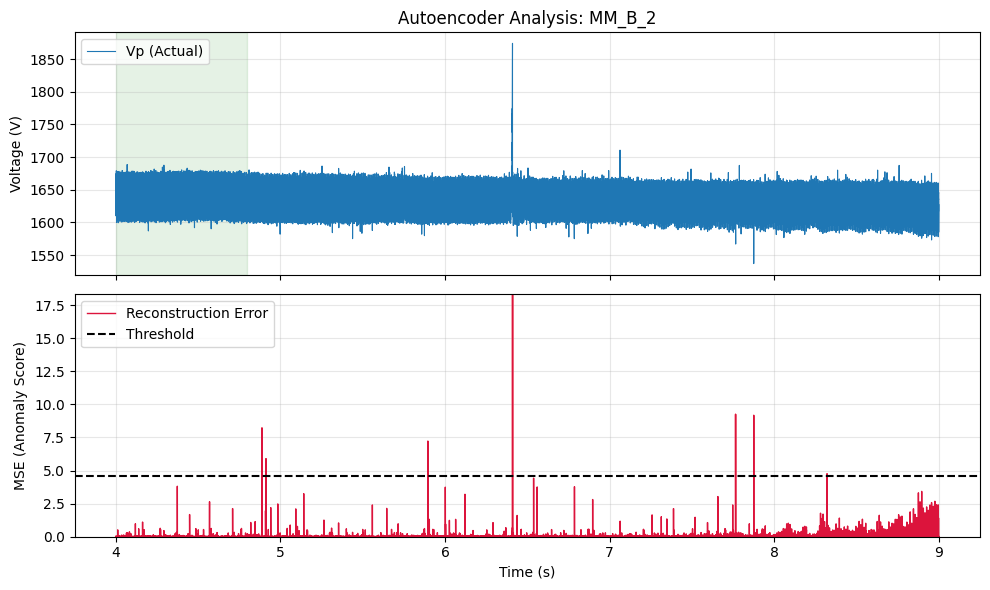

C:\Users\lucas\AppData\Local\Temp\ipykernel_95408\2023551968.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trend_vp = df['Vp'].rolling(TREND_WINDOW).median().fillna(method='bfill')


--- MM_B_3 ---
ARC DETECTED AT: 44.0078 s


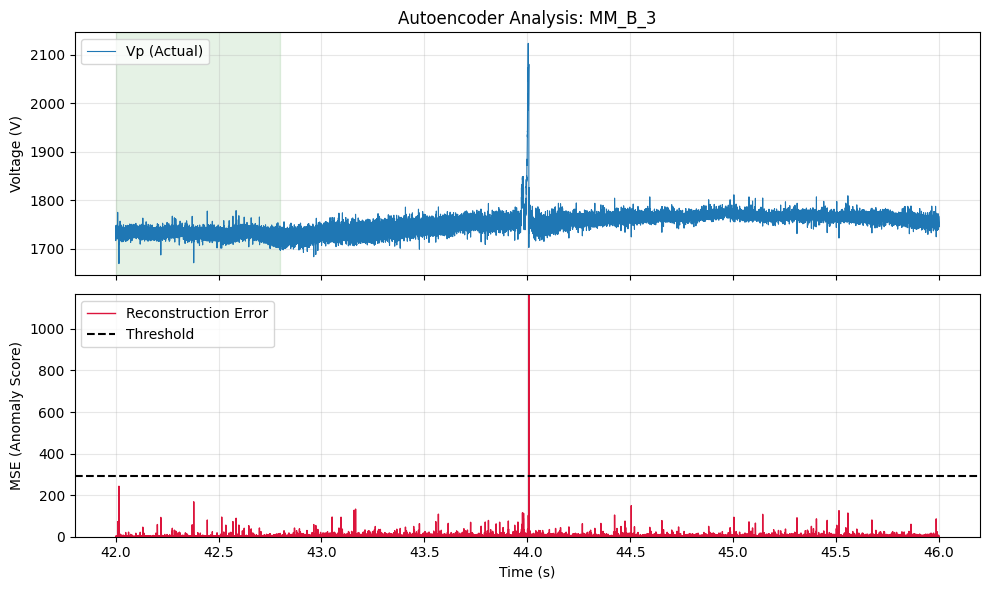

C:\Users\lucas\AppData\Local\Temp\ipykernel_95408\2023551968.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trend_vp = df['Vp'].rolling(TREND_WINDOW).median().fillna(method='bfill')


--- MM_B_4 ---
ARC DETECTED AT: 127.6322 s


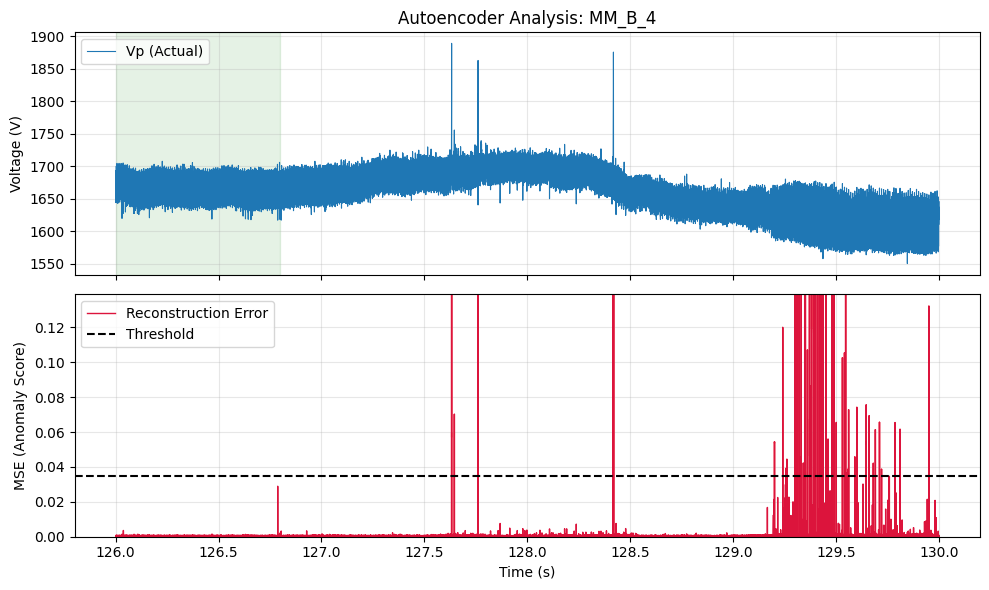

C:\Users\lucas\AppData\Local\Temp\ipykernel_95408\2023551968.py:31: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trend_vp = df['Vp'].rolling(TREND_WINDOW).median().fillna(method='bfill')


--- MM_B_5 ---
ARC DETECTED AT: 41.5174 s


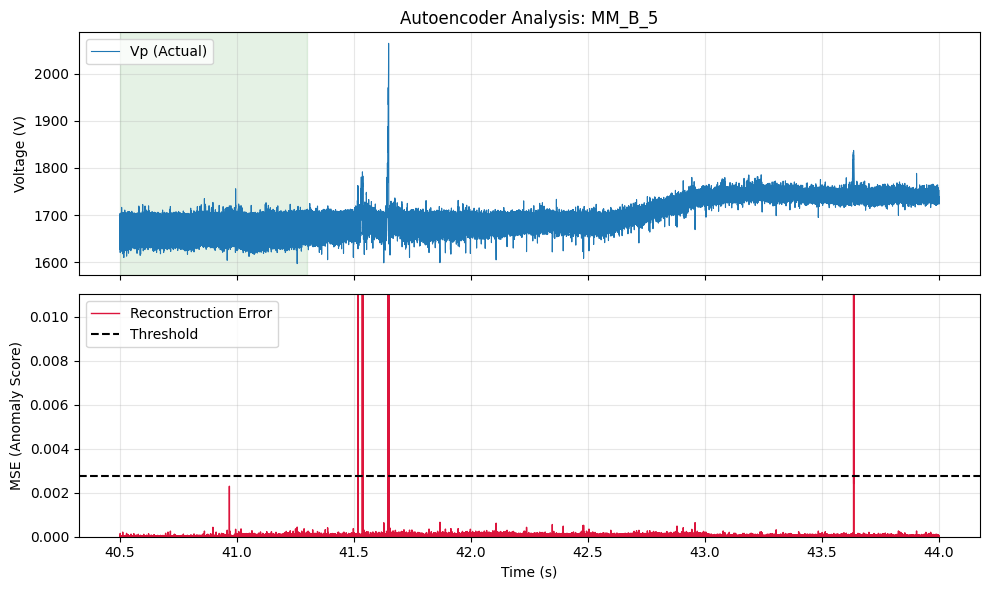

In [ ]:
TREND_WINDOW = 50
NUM_TRAIN_POINTS = 40000  # Training on "stable" phase
THRESHOLD_MARGIN = 1.2    # Safety margin above max noise (20%)

files = sorted(glob.glob("MM_B_*_Vp.txt"))

for vp_file in files:
    ID_TO_TEST = "_".join(vp_file.split('_')[:3])
    
    try:
        # 1. LOAD DATA
        vp = pd.read_csv(f"{ID_TO_TEST}_Vp.txt", header=None, names=["Vp"])
        time_data = pd.read_csv(f"{ID_TO_TEST}_x.txt", header=None, names=["Time"])
        
        min_len = min(len(vp), len(time_data))
        df = pd.concat([time_data.iloc[:min_len], vp.iloc[:min_len]], axis=1)
        
        # 2. FEATURE ENGINEERING
        # Trend (Rolling Median)
        trend_vp = df['Vp'].rolling(TREND_WINDOW).median().fillna(method='bfill')
        
        # Feature 1: Residual (Deviation from trend)
        df['Residual'] = (df['Vp'] - trend_vp).abs()
        
        # Feature 2: Velocity (Derivative to catch fast changes)
        df['Velocity'] = df['Vp'].diff().abs().fillna(0)
        
        # Prepare data for the network
        features_columns = ['Residual', 'Velocity']
        data = df[features_columns].values
        
        # 3. NORMALIZATION
        scaler = StandardScaler()
        # Fit scaler ONLY on training data to avoid data leakage
        scaler.fit(data[:NUM_TRAIN_POINTS])
        data_scaled = scaler.transform(data)
        
        X_train = data_scaled[:NUM_TRAIN_POINTS]
        
        # 4. AUTOENCODER ARCHITECTURE
        input_dim = X_train.shape[1]
        
        input_layer = Input(shape=(input_dim,))
        
        # Encoder (Compression)
        encoder = Dense(8, activation="relu")(input_layer)
        encoder = Dense(4, activation="relu")(encoder)
        
        # Bottleneck (Latent space representation)
        bottleneck = Dense(2, activation="relu")(encoder)
        
        # Decoder (Reconstruction)
        decoder = Dense(4, activation="relu")(bottleneck)
        decoder = Dense(8, activation="relu")(decoder)
        output_layer = Dense(input_dim, activation="linear")(decoder)
        
        autoencoder = Model(inputs=input_layer, outputs=output_layer)
        
        # Compile and Train
        autoencoder.compile(optimizer='adam', loss='mse')
        
        # Fast training (20 epochs is usually sufficient for simple signals)
        autoencoder.fit(X_train, X_train, 
                        epochs=20, 
                        batch_size=32, 
                        shuffle=True, 
                        verbose=0)
        
        # 5. DETECTION (Reconstruction Error)
        reconstructions = autoencoder.predict(data_scaled, verbose=0)
        
        # MSE Calculation: Mean Squared Error between input and output
        mse = np.mean(np.power(data_scaled - reconstructions, 2), axis=1)
        
        df['Reconstruction_Error'] = mse
        
        # Smooth error to avoid single-point false positives
        df['Error_Smoothed'] = df['Reconstruction_Error'].rolling(5).mean().fillna(0)

        # 6. DYNAMIC THRESHOLD
        # Based on max error during the training (stable) phase
        max_train_error = df['Error_Smoothed'].iloc[:NUM_TRAIN_POINTS].max()
        threshold = max_train_error * THRESHOLD_MARGIN
        
        # Detect anomalies
        anomalies = df[(df['Error_Smoothed'] > threshold) & (df.index > NUM_TRAIN_POINTS)]
        
        print(f"--- {ID_TO_TEST} ---")
        if not anomalies.empty:
            t_first = anomalies['Time'].iloc[0]
            print(f"ARC DETECTED AT: {t_first:.4f} s")
        else:
            print("No arc detected.")

        # 7. PLOTTING
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

        # TOP: Physical Signal
        ax1.plot(df['Time'], df['Vp'], label='Vp (Actual)', color='#1f77b4', linewidth=0.8)
        # Highlight training zone
        ax1.axvspan(df['Time'].iloc[0], df['Time'].iloc[NUM_TRAIN_POINTS], color='green', alpha=0.1)
        ax1.set_ylabel("Voltage (V)")
        ax1.legend(loc='upper left')
        ax1.set_title(f"Autoencoder Analysis: {ID_TO_TEST}")
        ax1.grid(True, alpha=0.3)

        # BOTTOM: Reconstruction Error
        ax2.plot(df['Time'], df['Error_Smoothed'], color='crimson', linewidth=1, label="Reconstruction Error")
        ax2.axhline(threshold, color='black', linestyle='--', linewidth=1.5, label="Threshold")
        
        # Fill area above threshold
        ax2.fill_between(df['Time'], 0, df['Error_Smoothed'], 
                         where=(df['Error_Smoothed'] > threshold), color='red', alpha=0.5)

        # Smart Zoom on Y-axis
        ax2.set_ylim(0, threshold * 4)
        
        ax2.set_ylabel("MSE (Anomaly Score)")
        ax2.set_xlabel("Time (s)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error processing {ID_TO_TEST}: {e}")

3 arcs detected in advance, all 5 detected when they occur